In [1]:
import numpy as np
import MAS_library as MASL
import Pk_library as PKL
import readgadget
import readfof

from astropy.table import Table, join
import os

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')

In [2]:
base = '../data/astra/fiducial_0'
# !ls ../data/astra/fiducial_0/raw

In [3]:
tab = Table.read(f'{base}/raw/zone_00_sim000_snap003.fits.gz')
len(tab)

714472

In [4]:
real_data = tab[tab['RANDITER']==-1]
len(real_data)

15532

In [5]:
pos = np.column_stack([real_data['XCART'], real_data['YCART'],real_data['ZCART']]).astype(np.float32)

pos = np.ascontiguousarray(pos)

print('shape:', pos.shape)
print('dtype:', pos.dtype)
print('min:', pos.min(axis=0))
print('max:', pos.max(axis=0))

shape: (15532, 3)
dtype: float32
min: [0.11795123 0.10009713 0.02645912]
max: [999.92    999.83496 999.89514]


In [6]:
grid = 512
MAS = 'CIC'
verbose = True

axis = 0
threads = 1
BoxSize = 1000.0

In [7]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)

MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)

delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))


Using CIC mass assignment scheme
Time taken = 0.076 seconds

-1.000 < delta < 8540.422
< delta > = -0.000


In [8]:
# compute power spectrum
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

# Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# 1D P(k)
k1D = Pk.k1D
Pk1D = Pk.Pk1D
Nmodes1D = Pk.Nmodes1D

# 2D P(k)
kpar = Pk.kpar
kper = Pk.kper
Pk2D = Pk.Pk2D
Nmodes2D = Pk.Nmodes2D

# 3D P(k)
k = Pk.k3D
Pk0 = Pk.Pk[:,0] #monopole
Pk2 = Pk.Pk[:,1] #quadrupole
Pk4 = Pk.Pk[:,2] #hexadecapole
Pkphase = Pk.Pkphase #power spectrum of the phases
Nmodes = Pk.Nmodes3D


Computing power spectrum of the field...
Time to complete loop = 4.73
Time taken = 7.88 seconds


In [11]:
Nhalos = len(pos)
volume = BoxSize**3
nbar = Nhalos / volume
Pshot = 1.0 / nbar

print('N halos:', Nhalos)
print('nbar:', nbar, '(h/Mpc)^3')
print('Pshot:', Pshot, '(Mpc/h)^3')

N halos: 15532
nbar: 1.5532e-05 (h/Mpc)^3
Pshot: 64383.20885912954 (Mpc/h)^3


In [12]:
k_nyquist = np.pi * grid / BoxSize

mask = (np.isfinite(k) & np.isfinite(Pk0) & (Nmodes > 0)
        & (k > 0) & (k <= 0.5))

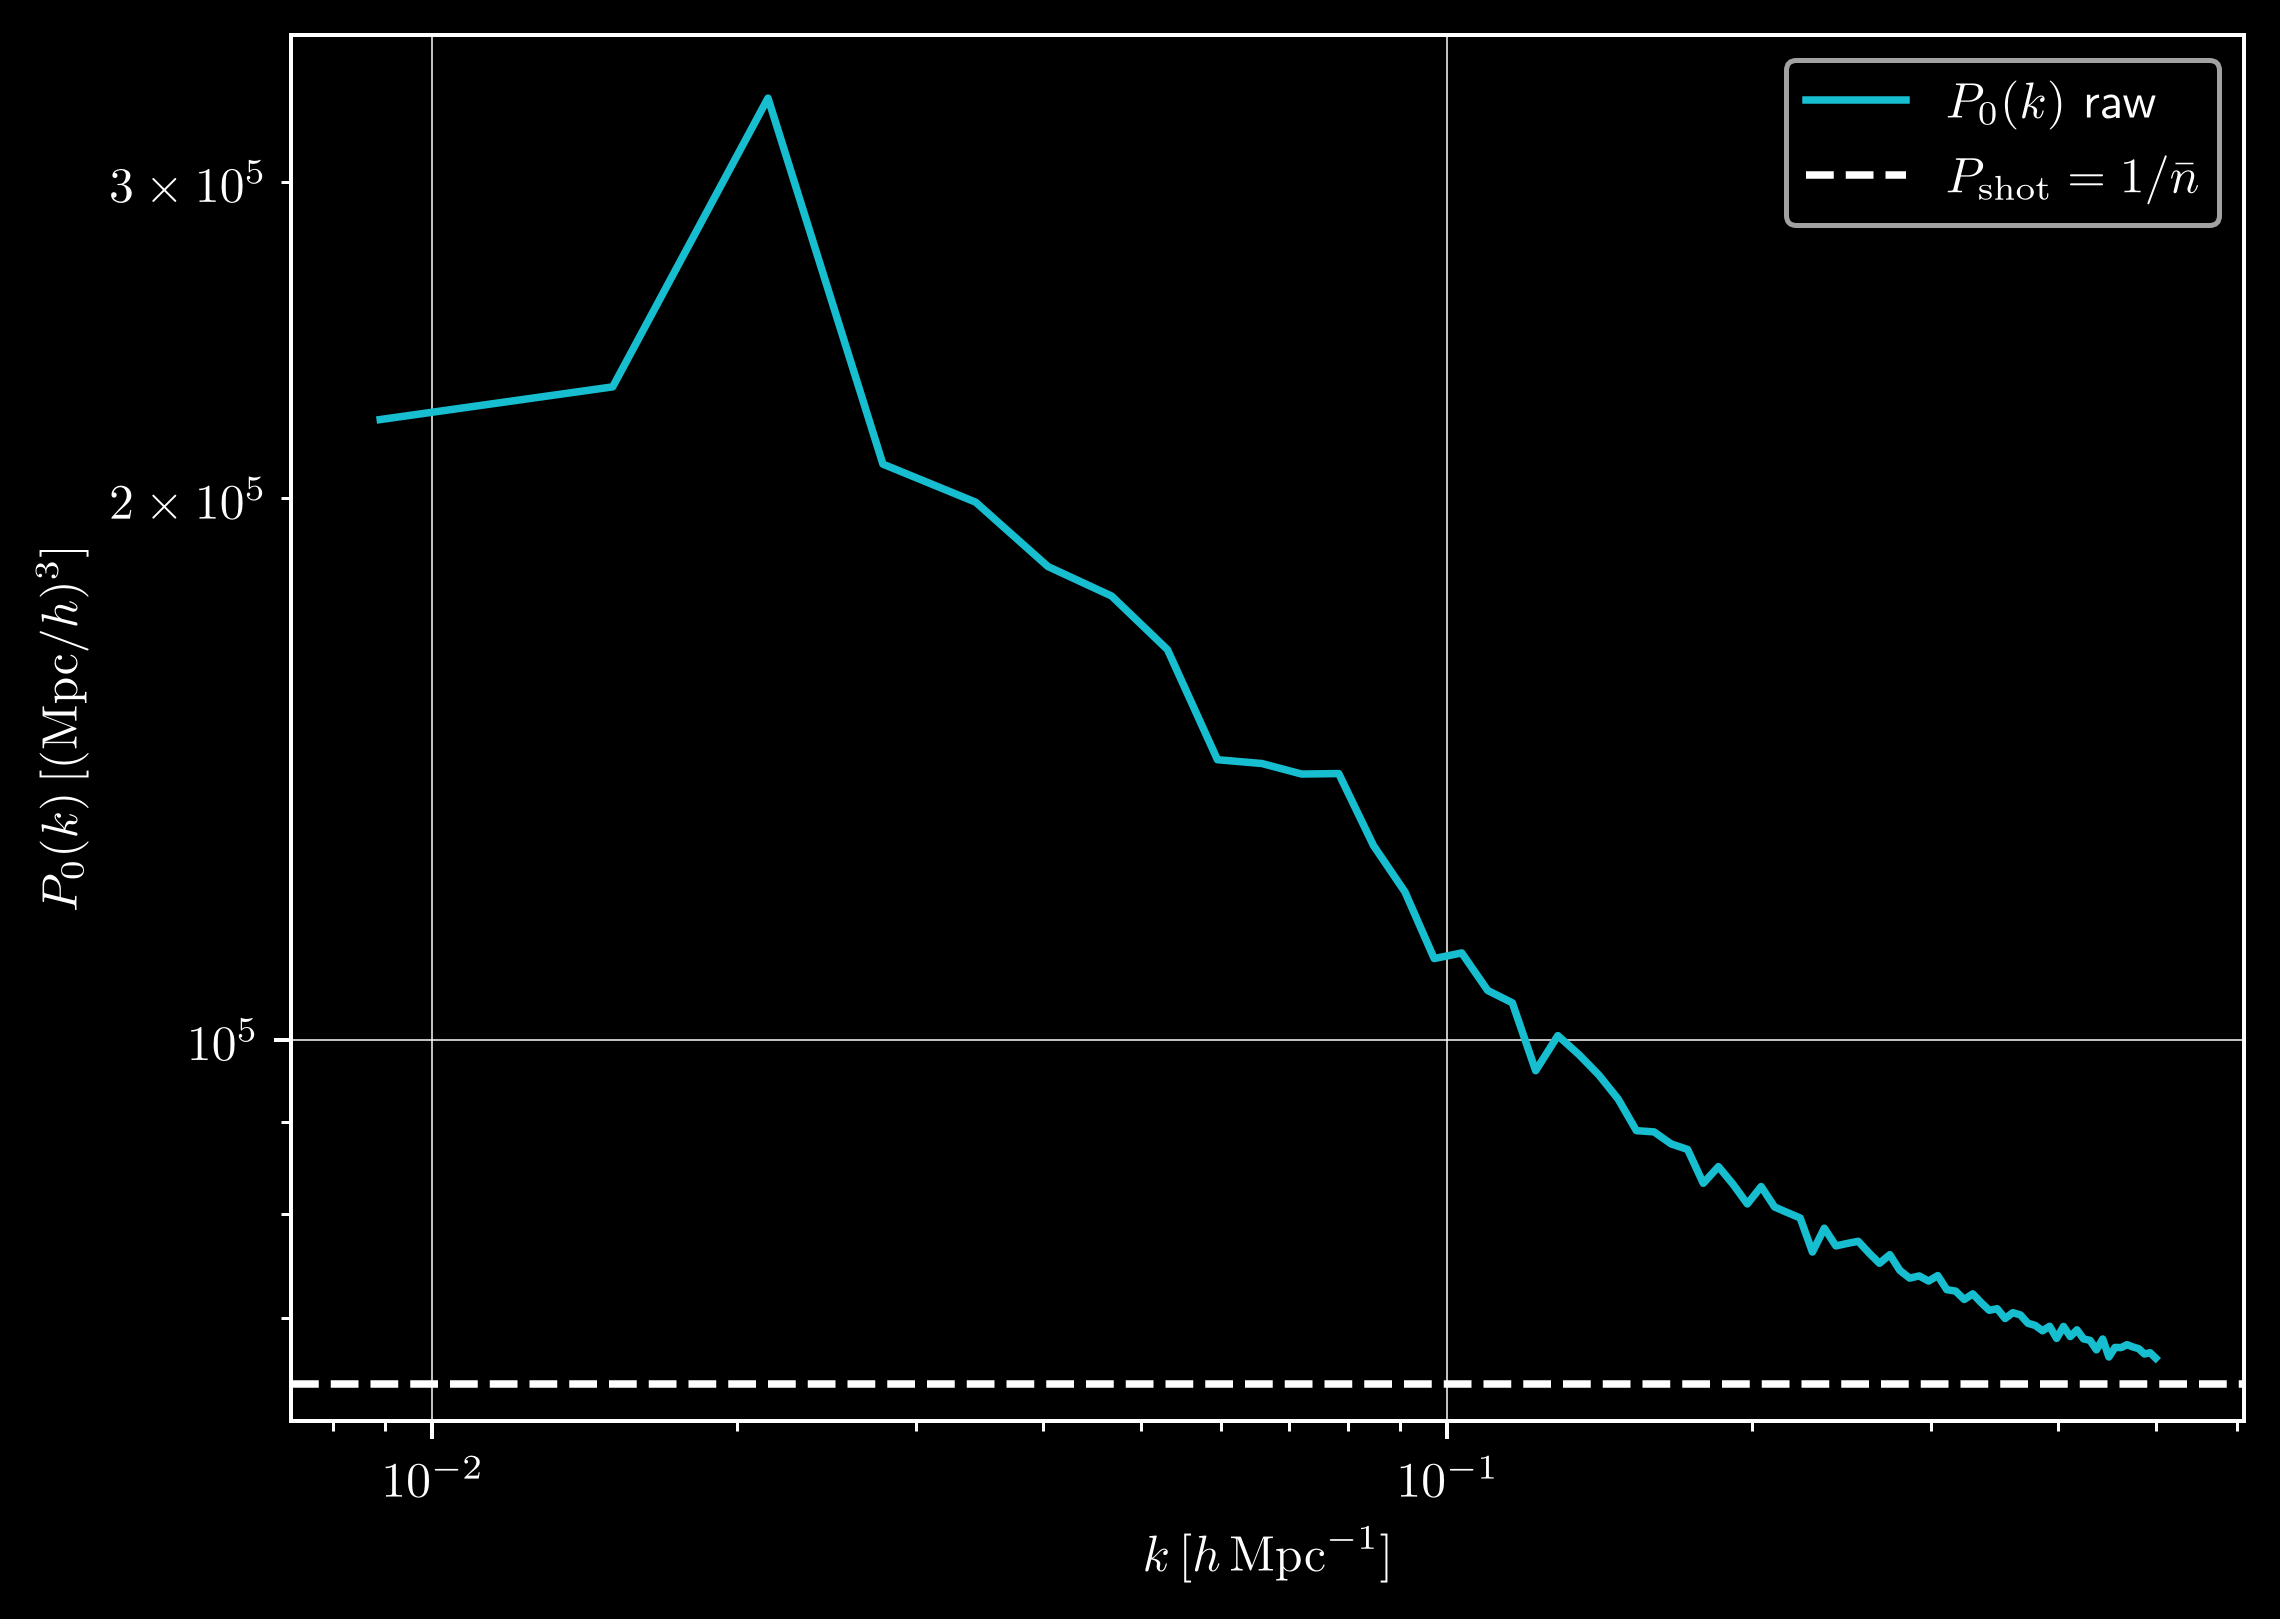

k Nyquist = 1.608 h/Mpc


In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.loglog(k[mask], Pk0[mask], label=r'$P_0(k)$ raw', c='#17becf')

ax.axhline(Pshot,linestyle='--', label=r'$P_{\rm shot}=1/\bar{n}$')

ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.legend()

plt.show()

print(f'k Nyquist = {k_nyquist:.3f} h/Mpc')

In [14]:
for ki, pi, ni in zip(k[:10], Pk0[:10], Nmodes[:10]):
    print(f'k={ki:.5f}, P0={pi:.4e}, Nmodes={ni}')

k=0.00890, P0=2.2123e+05, Nmodes=13.0
k=0.01508, P0=2.3069e+05, Nmodes=33.0
k=0.02145, P0=3.3387e+05, Nmodes=79.0
k=0.02784, P0=2.0896e+05, Nmodes=117.0
k=0.03435, P0=1.9903e+05, Nmodes=205.0
k=0.04048, P0=1.8328e+05, Nmodes=235.0
k=0.04677, P0=1.7649e+05, Nmodes=369.0
k=0.05308, P0=1.6478e+05, Nmodes=433.0
k=0.05945, P0=1.4312e+05, Nmodes=585.0
k=0.06576, P0=1.4243e+05, Nmodes=679.0


In [15]:
Nhalos = len(pos)
volume = BoxSize**3

nbar = Nhalos / volume
Pshot = 1.0 / nbar

Pk_clustering = Pk0 - Pshot

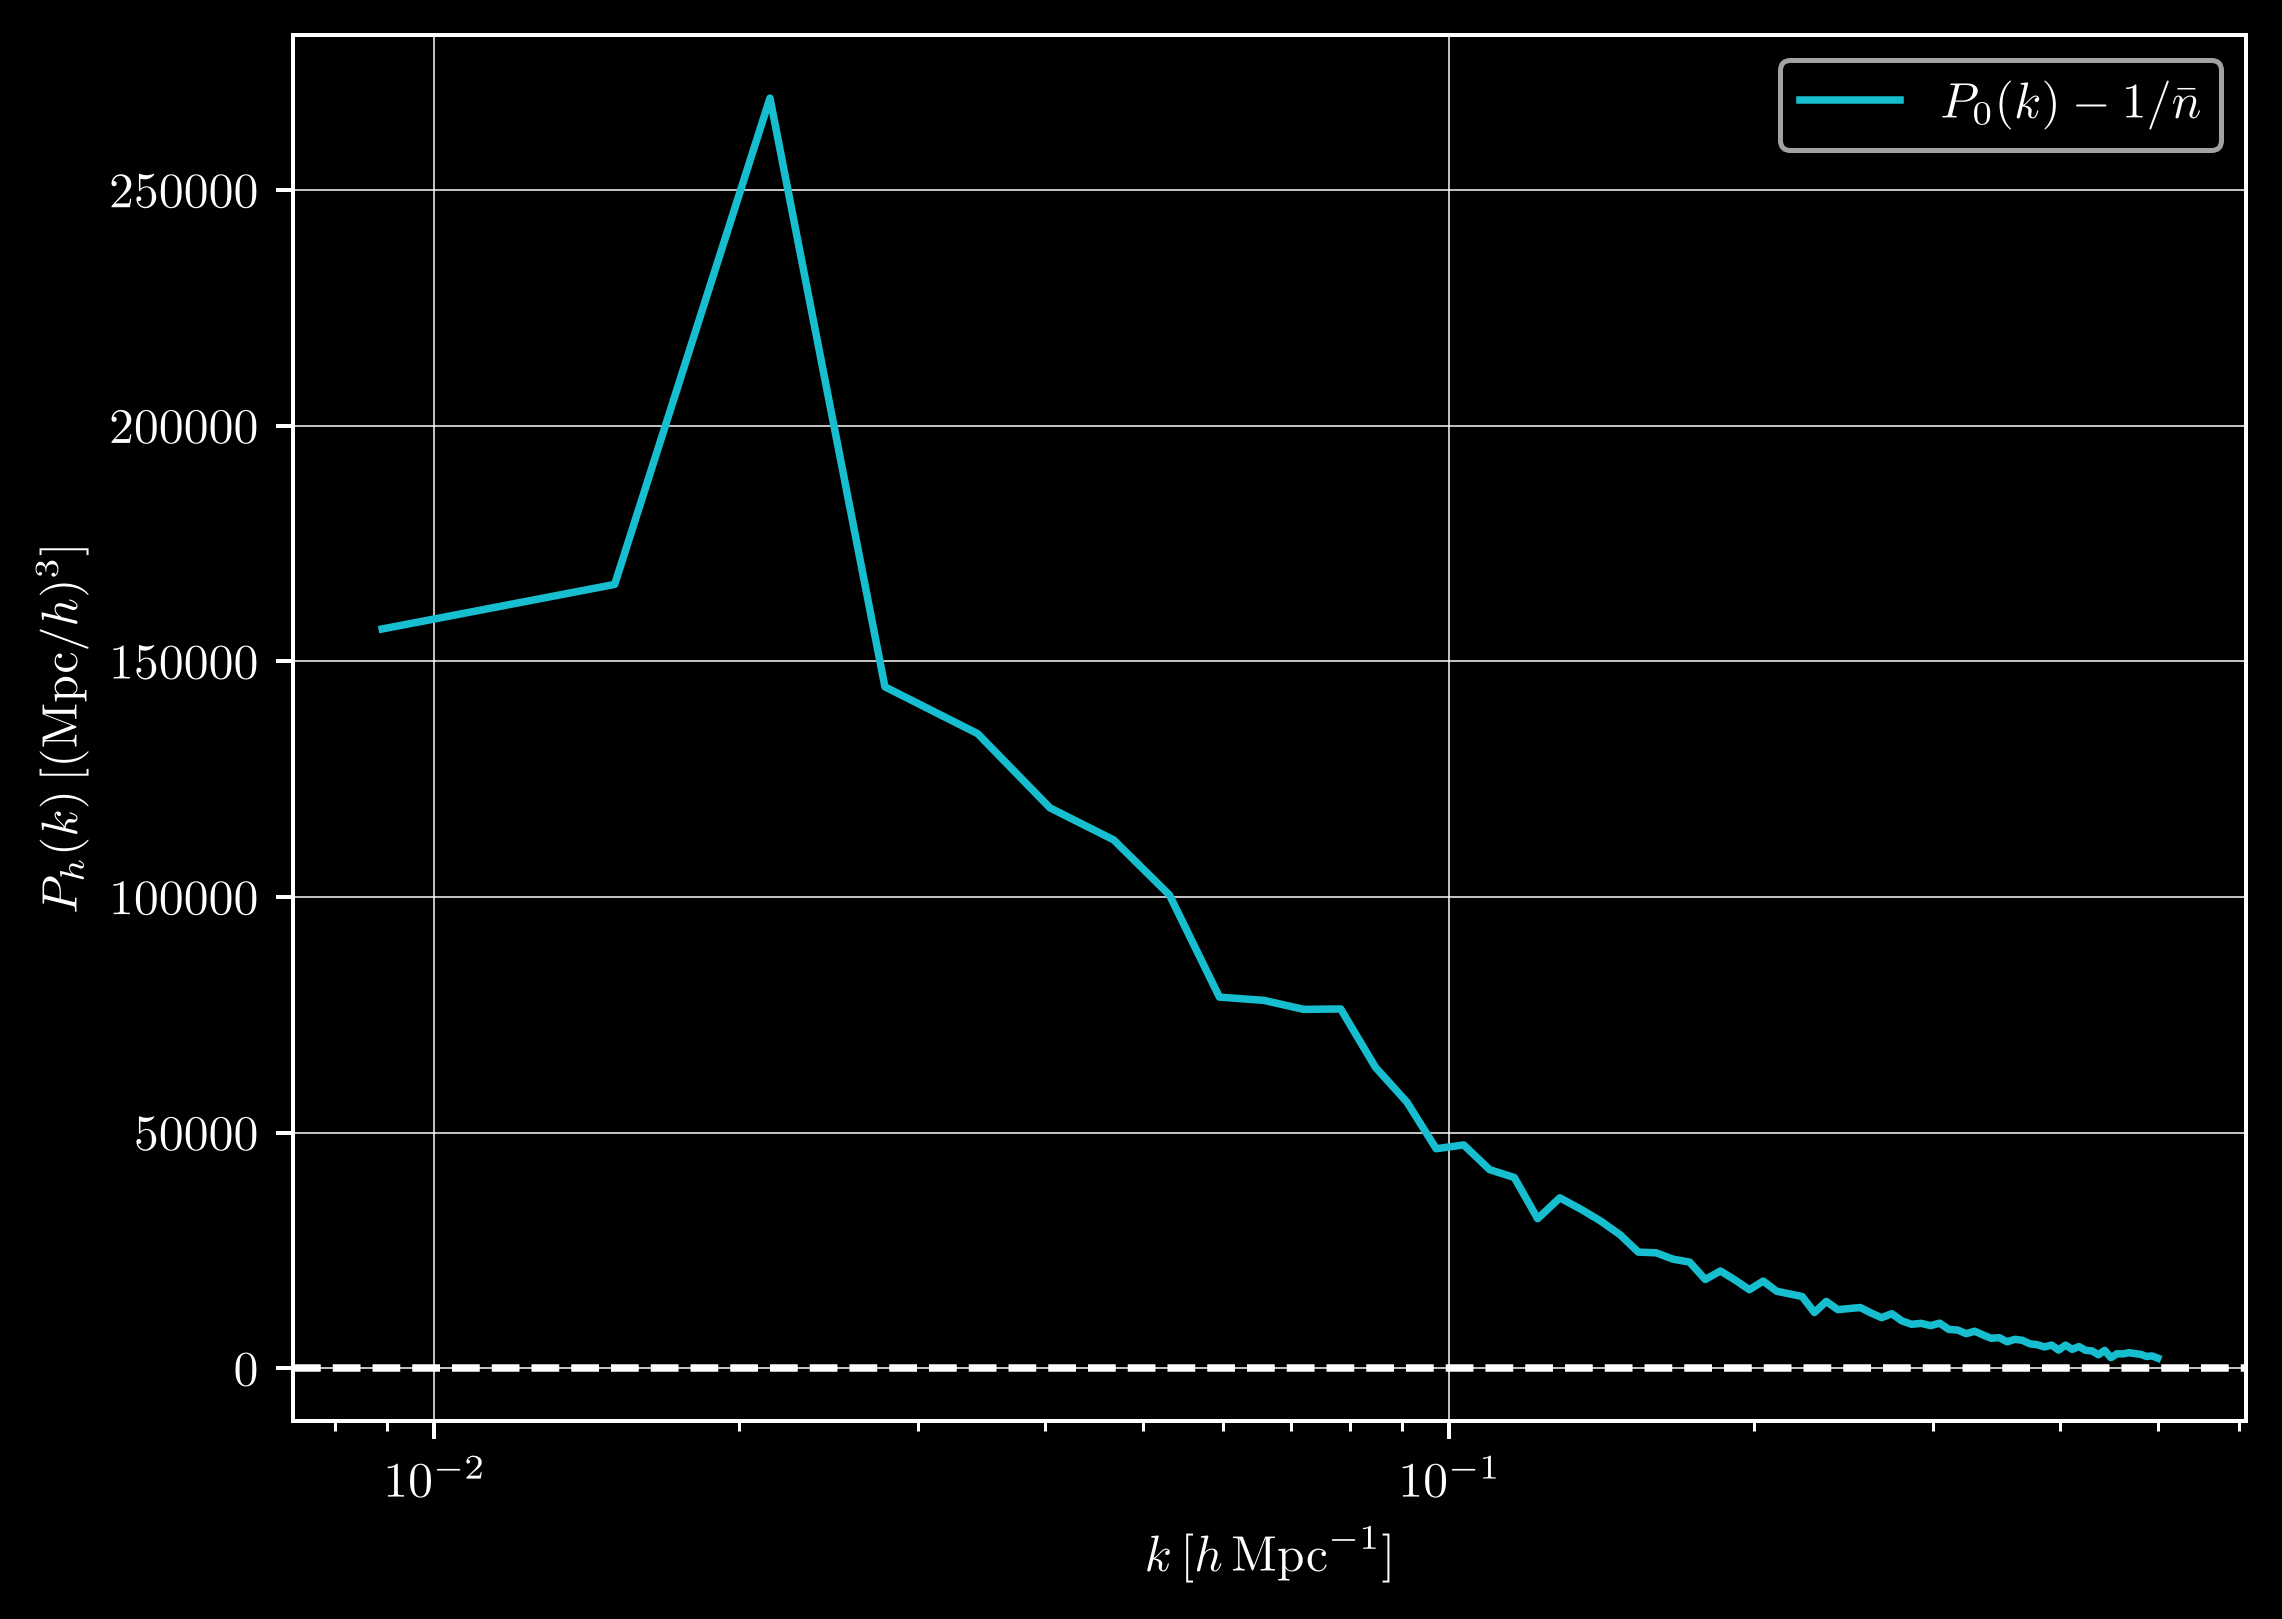

In [30]:
mask = (np.isfinite(k) & np.isfinite(Pk_clustering) & (Nmodes > 0)
        & (k >= 0.008) & (k <= 0.5))

fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.semilogx(k[mask], Pk_clustering[mask], label=r'$P_0(k)-1/\bar n$', c='#17becf')

ax.axhline(0.0, linestyle='--')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_h(k)\,[(\mathrm{Mpc}/h)^3]$')

plt.legend()
plt.show()

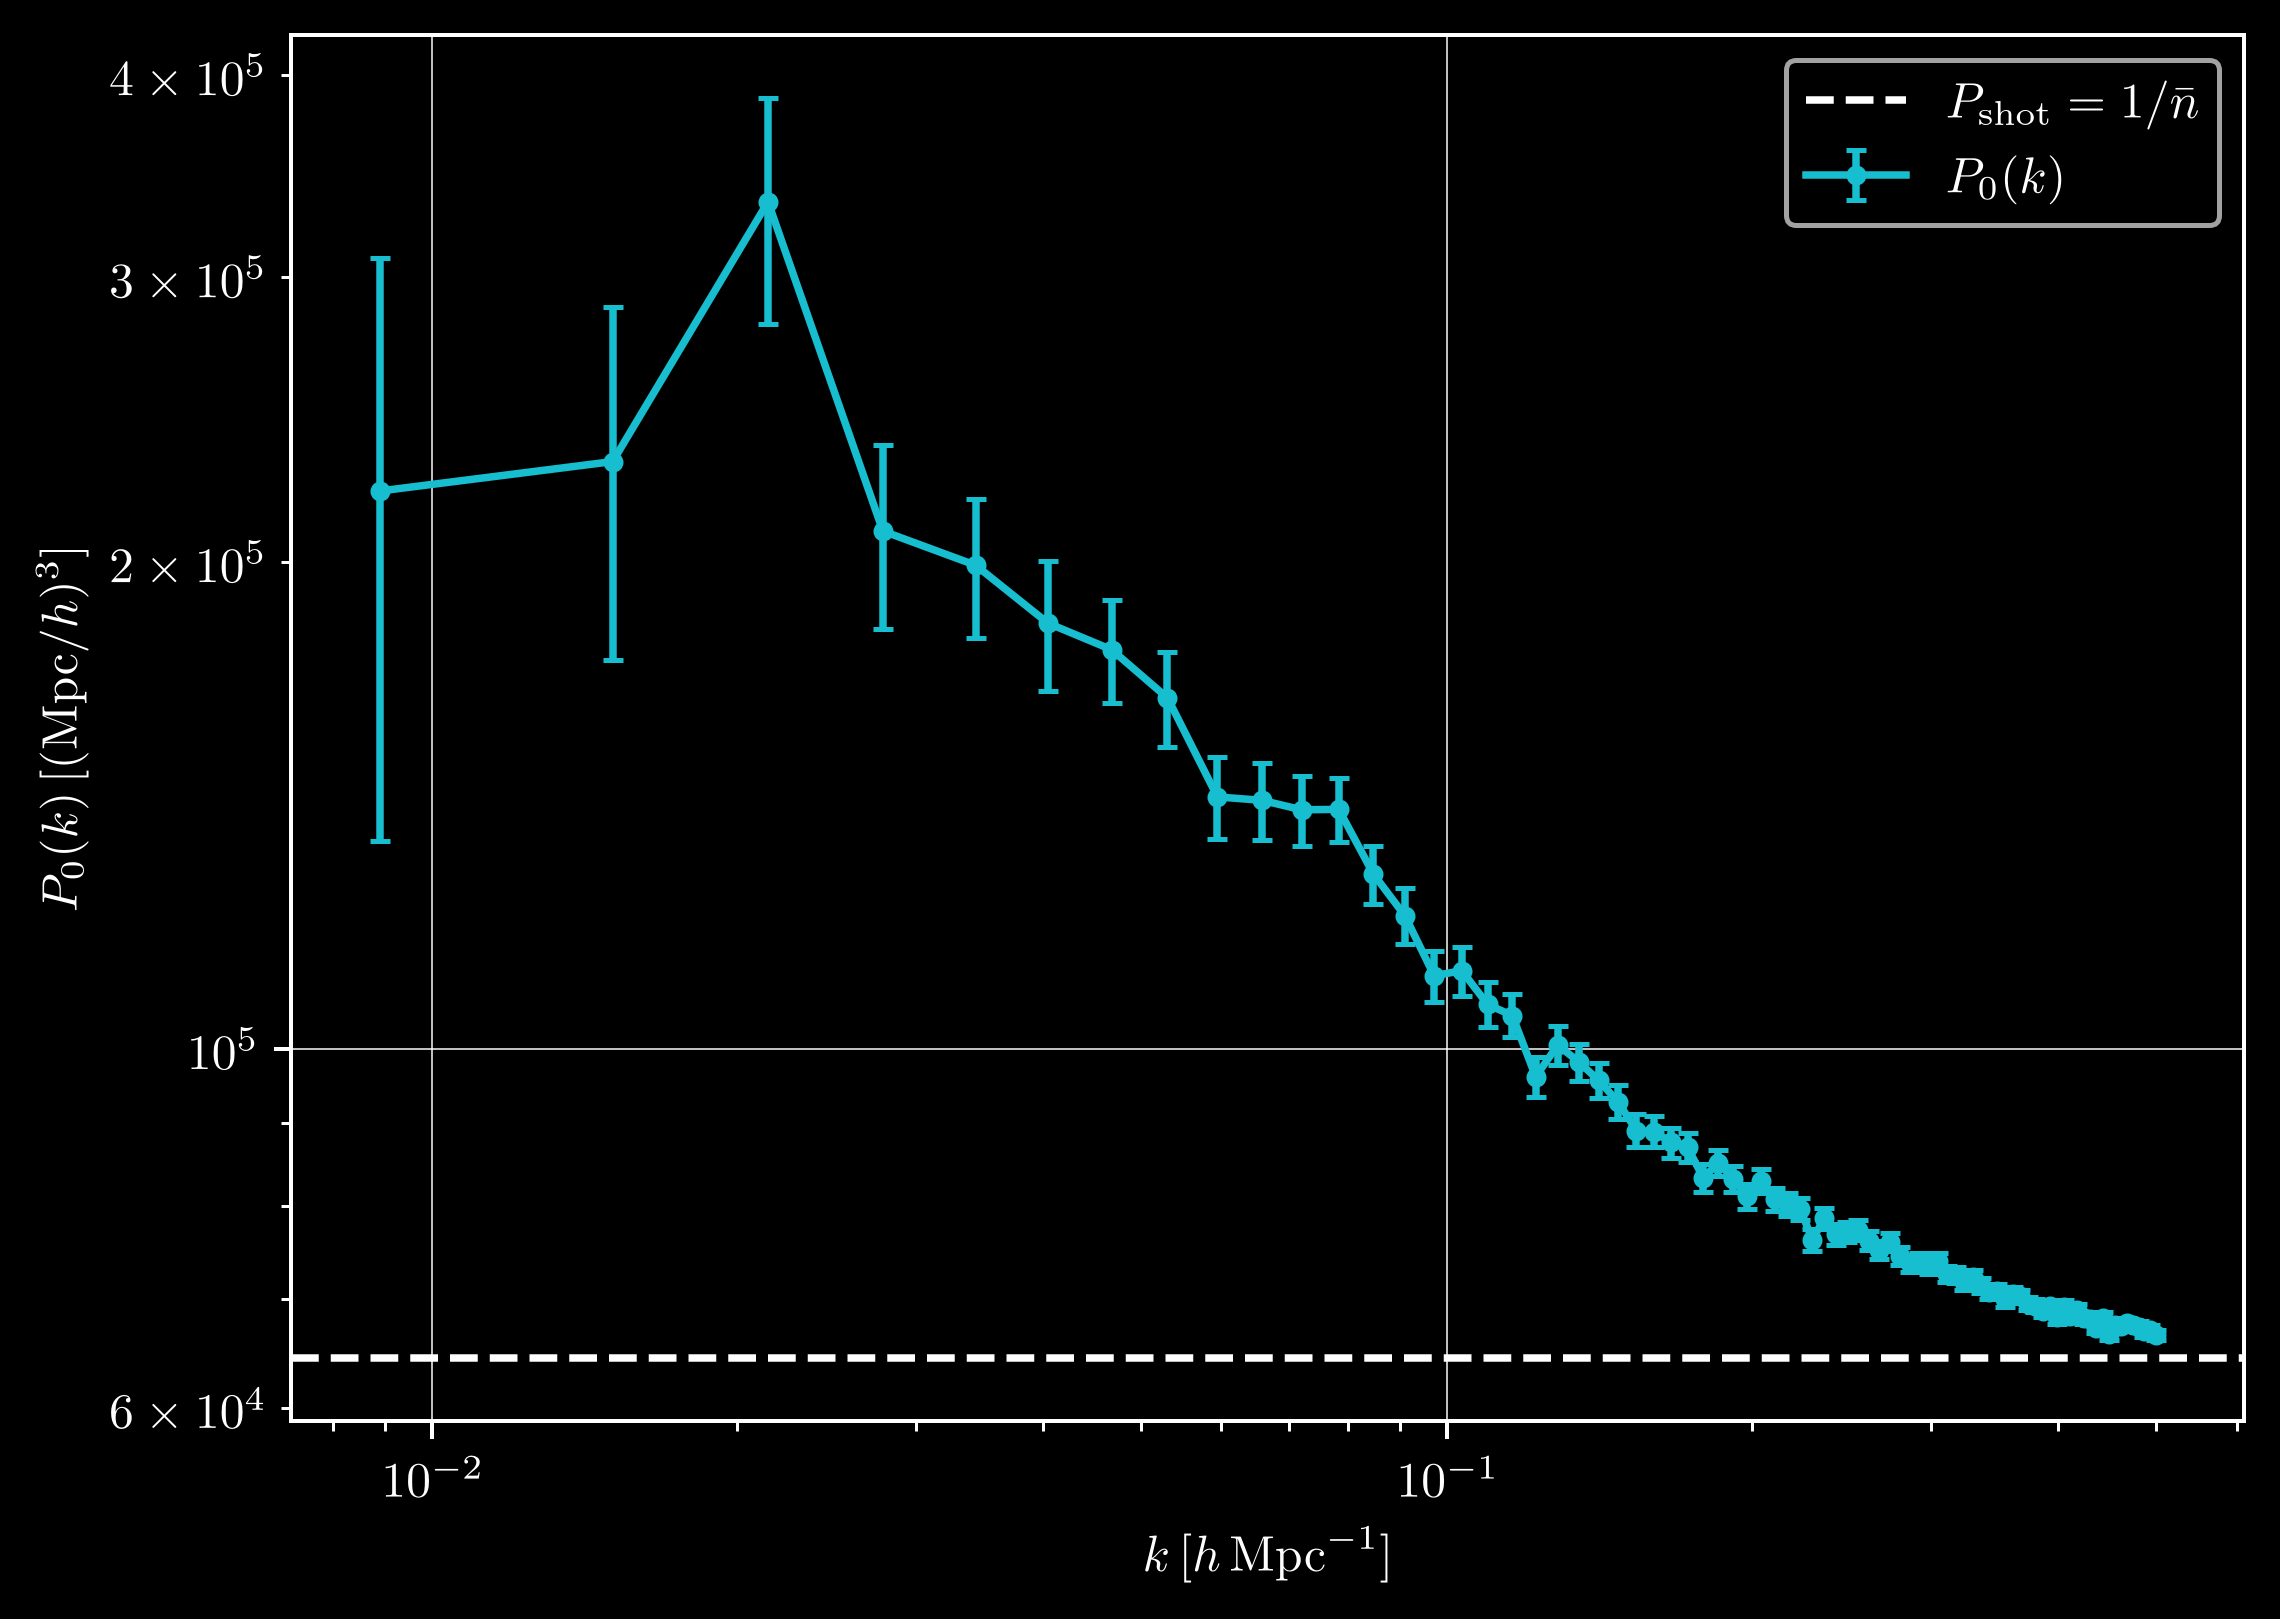

In [31]:
sigma_P = Pk0 * np.sqrt(2.0 / Nmodes)

mask = (np.isfinite(k) & np.isfinite(Pk0) & np.isfinite(sigma_P)
        & (Nmodes > 0) & (k >= 0.008) & (k <= 0.5))

fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask], fmt='.-',
            capsize=2, label=r'$P_0(k)$', c='#17becf')

ax.axhline(Pshot, linestyle='--', label=r'$P_{\rm shot}=1/\bar n$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.legend()

plt.show()

### Envs

In [5]:
prob = Table.read(f'{base}/astra/probabilities/sim000/00/zone_00_sim000_snap003_probability_iterdata.fits.gz', hdu=1)
prob[:5]

TARGETID,TRACERTYPE,PVOID,PSHEET,PFILAMENT,PKNOT
int64,bytes24,float32,float32,float32,float32
1,HALO,0.0,0.4888889,0.51111114,0.0
2,HALO,0.0,0.6888889,0.31111112,0.0
3,HALO,0.4,0.6,0.0,0.0
4,HALO,0.0,0.26666668,0.62222224,0.11111111
5,HALO,0.044444446,0.7777778,0.17777778,0.0


In [6]:
tab_final = join(real_data, prob, keys='TARGETID', join_type='inner')
tab_final[:5]

TARGETID,TRACERTYPE_1,TRACER_ID,RANDITER,ZONE,XCART,YCART,ZCART,MASS,VEL_X,VEL_Y,VEL_Z,NPART,TRACERTYPE_2,PVOID,PSHEET,PFILAMENT,PKNOT
int64,bytes4,uint8,int32,int32,float64,float64,float64,float64,float64,float64,float64,int32,bytes24,float32,float32,float32,float32
1,HALO,0,-1,0,180.145515625,779.8080625,774.2938125,2148271406250000.0,583.763671875,8.426266193389893,82.44683074951172,409,HALO,0.0,0.4888889,0.51111114,0.0
2,HALO,0,-1,0,988.2470625,204.682859375,306.11725,1854131406250000.0,356.8798599243164,113.75636672973633,-634.1008758544922,353,HALO,0.0,0.6888889,0.31111112,0.0
3,HALO,0,-1,0,464.81653125,154.60196875,120.41453125,1696556406250000.0,-187.55950927734375,-382.24303436279297,-276.5127410888672,323,HALO,0.4,0.6,0.0,0.0
4,HALO,0,-1,0,610.7565625,643.401625,502.80390625,1628273906250000.0,286.52913665771484,-254.7633819580078,-225.44721221923828,310,HALO,0.0,0.26666668,0.62222224,0.11111111
5,HALO,0,-1,0,381.04565625,600.464125,416.7123125,1538981406250000.0,-185.65877151489258,351.1797180175781,-272.8007354736328,293,HALO,0.044444446,0.7777778,0.17777778,0.0


In [7]:
prob_cols = ['PVOID', 'PSHEET', 'PFILAMENT', 'PKNOT']
class_names = np.array(['Void', 'Sheet', 'Filament', 'Knot'])

In [8]:
prob_matrix = np.column_stack([np.asarray(tab_final[col], dtype=float)
                               for col in prob_cols])

max_idx = np.argmax(prob_matrix, axis=1)

In [9]:
tab_final['CLASS'] = class_names[max_idx]
tab_final['PROB'] = prob_matrix[np.arange(len(tab_final)),
                                                   max_idx]
tab_final[:5]

TARGETID,TRACERTYPE_1,TRACER_ID,RANDITER,ZONE,XCART,YCART,ZCART,MASS,VEL_X,VEL_Y,VEL_Z,NPART,TRACERTYPE_2,PVOID,PSHEET,PFILAMENT,PKNOT,CLASS,PROB
int64,bytes4,uint8,int32,int32,float64,float64,float64,float64,float64,float64,float64,int32,bytes24,float32,float32,float32,float32,str8,float64
1,HALO,0,-1,0,180.145515625,779.8080625,774.2938125,2148271406250000.0,583.763671875,8.426266193389893,82.44683074951172,409,HALO,0.0,0.4888889,0.51111114,0.0,Filament,0.5111111402511597
2,HALO,0,-1,0,988.2470625,204.682859375,306.11725,1854131406250000.0,356.8798599243164,113.75636672973633,-634.1008758544922,353,HALO,0.0,0.6888889,0.31111112,0.0,Sheet,0.6888889074325562
3,HALO,0,-1,0,464.81653125,154.60196875,120.41453125,1696556406250000.0,-187.55950927734375,-382.24303436279297,-276.5127410888672,323,HALO,0.4,0.6,0.0,0.0,Sheet,0.6000000238418579
4,HALO,0,-1,0,610.7565625,643.401625,502.80390625,1628273906250000.0,286.52913665771484,-254.7633819580078,-225.44721221923828,310,HALO,0.0,0.26666668,0.62222224,0.11111111,Filament,0.6222222447395325
5,HALO,0,-1,0,381.04565625,600.464125,416.7123125,1538981406250000.0,-185.65877151489258,351.1797180175781,-272.8007354736328,293,HALO,0.044444446,0.7777778,0.17777778,0.0,Sheet,0.7777777910232544


In [10]:
voids = tab_final[tab_final['CLASS'] == 'Void']
sheets = tab_final[tab_final['CLASS'] == 'Sheet']
filaments = tab_final[tab_final['CLASS'] == 'Filament']
knots = tab_final[tab_final['CLASS'] == 'Knot']

len(voids), len(sheets), len(filaments), len(knots)

(2195, 10380, 2839, 118)

Voids

In [11]:
pos = np.array([voids['XCART'], voids['YCART'], voids['ZCART']]).astype(np.float32)
pos = np.ascontiguousarray(pos.T, dtype=np.float32)
pos

array([[561.96844, 839.83276, 647.95593],
       [556.0541 , 181.83502, 894.5312 ],
       [721.3339 , 284.5885 , 159.52995],
       ...,
       [970.39044, 766.29126, 574.0829 ],
       [857.4803 , 909.4819 , 842.6601 ],
       [876.7111 , 883.4549 , 754.90515]], dtype=float32)

In [12]:
grid = 512
MAS = 'CIC'
verbose = True

axis = 0
threads = 1
BoxSize = 1000.0

In [13]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)

In [14]:
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)


Using CIC mass assignment scheme
Time taken = 0.018 seconds



In [15]:
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))

-1.000 < delta < 58544.754
< delta > = -0.000


In [16]:
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

k = Pk.k3D
Pk0 = Pk.Pk[:,0]
Pkphase = Pk.Pkphase
Nmodes = Pk.Nmodes3D


Computing power spectrum of the field...


Time to complete loop = 8.24
Time taken = 13.08 seconds


In [17]:
sigma_P = Pk0 * np.sqrt(2.0 / Nmodes)

mask = (np.isfinite(k) & np.isfinite(Pk0) & np.isfinite(sigma_P)
        & (Nmodes > 0) & (k >= 0.008) & (k <= 0.5))

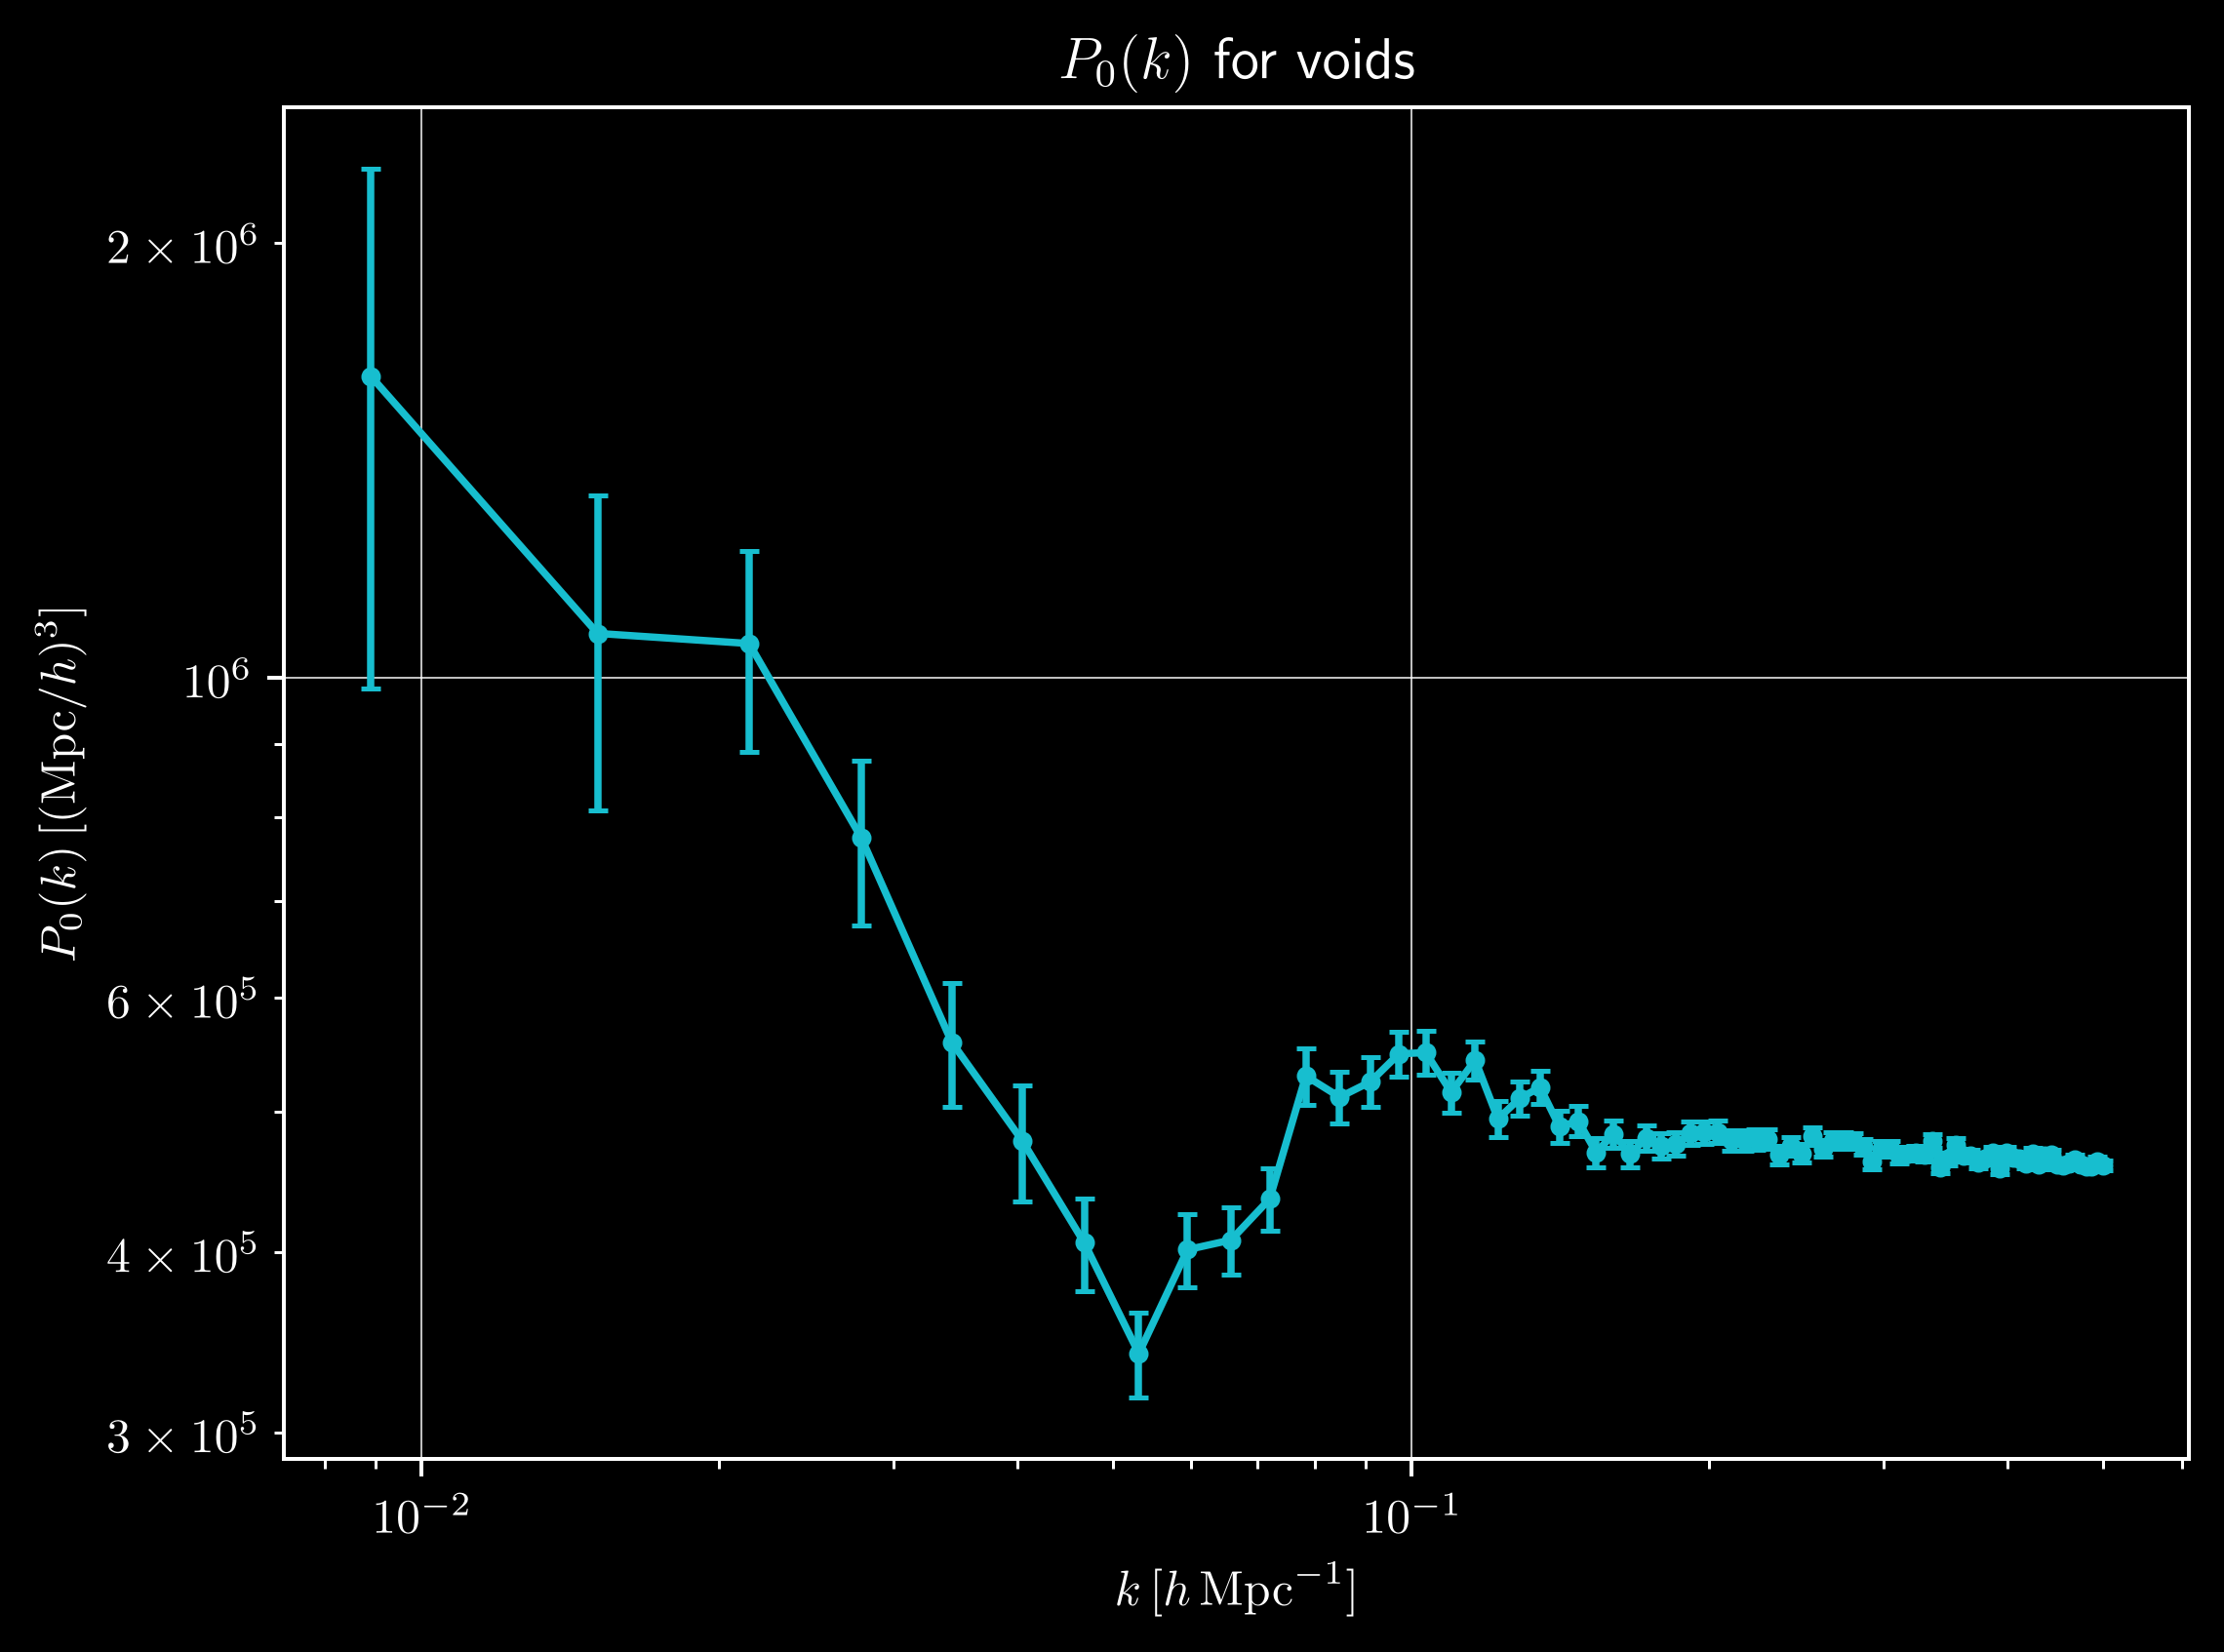

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask], fmt='.-',
            capsize=2, c='#17becf')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('$P_0(k)$ for voids')

plt.show()

Sheets

In [19]:
pos = np.array([sheets['XCART'], sheets['YCART'], sheets['ZCART']]).astype(np.float32)
pos = np.ascontiguousarray(pos.T, dtype=np.float32)

In [20]:
grid = 512
MAS = 'CIC'
verbose = True

axis = 0
threads = 1
BoxSize = 1000.0

In [21]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))


Using CIC mass assignment scheme
Time taken = 0.050 seconds

-1.000 < delta < 12779.863
< delta > = -0.000


In [22]:
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

k = Pk.k3D
Pk0 = Pk.Pk[:,0]
Pkphase = Pk.Pkphase
Nmodes = Pk.Nmodes3D


Computing power spectrum of the field...
Time to complete loop = 8.15
Time taken = 12.97 seconds


In [23]:
sigma_P = Pk0 * np.sqrt(2.0 / Nmodes)

mask = (np.isfinite(k) & np.isfinite(Pk0) & np.isfinite(sigma_P)
        & (Nmodes > 0) & (k >= 0.008) & (k <= 0.5))

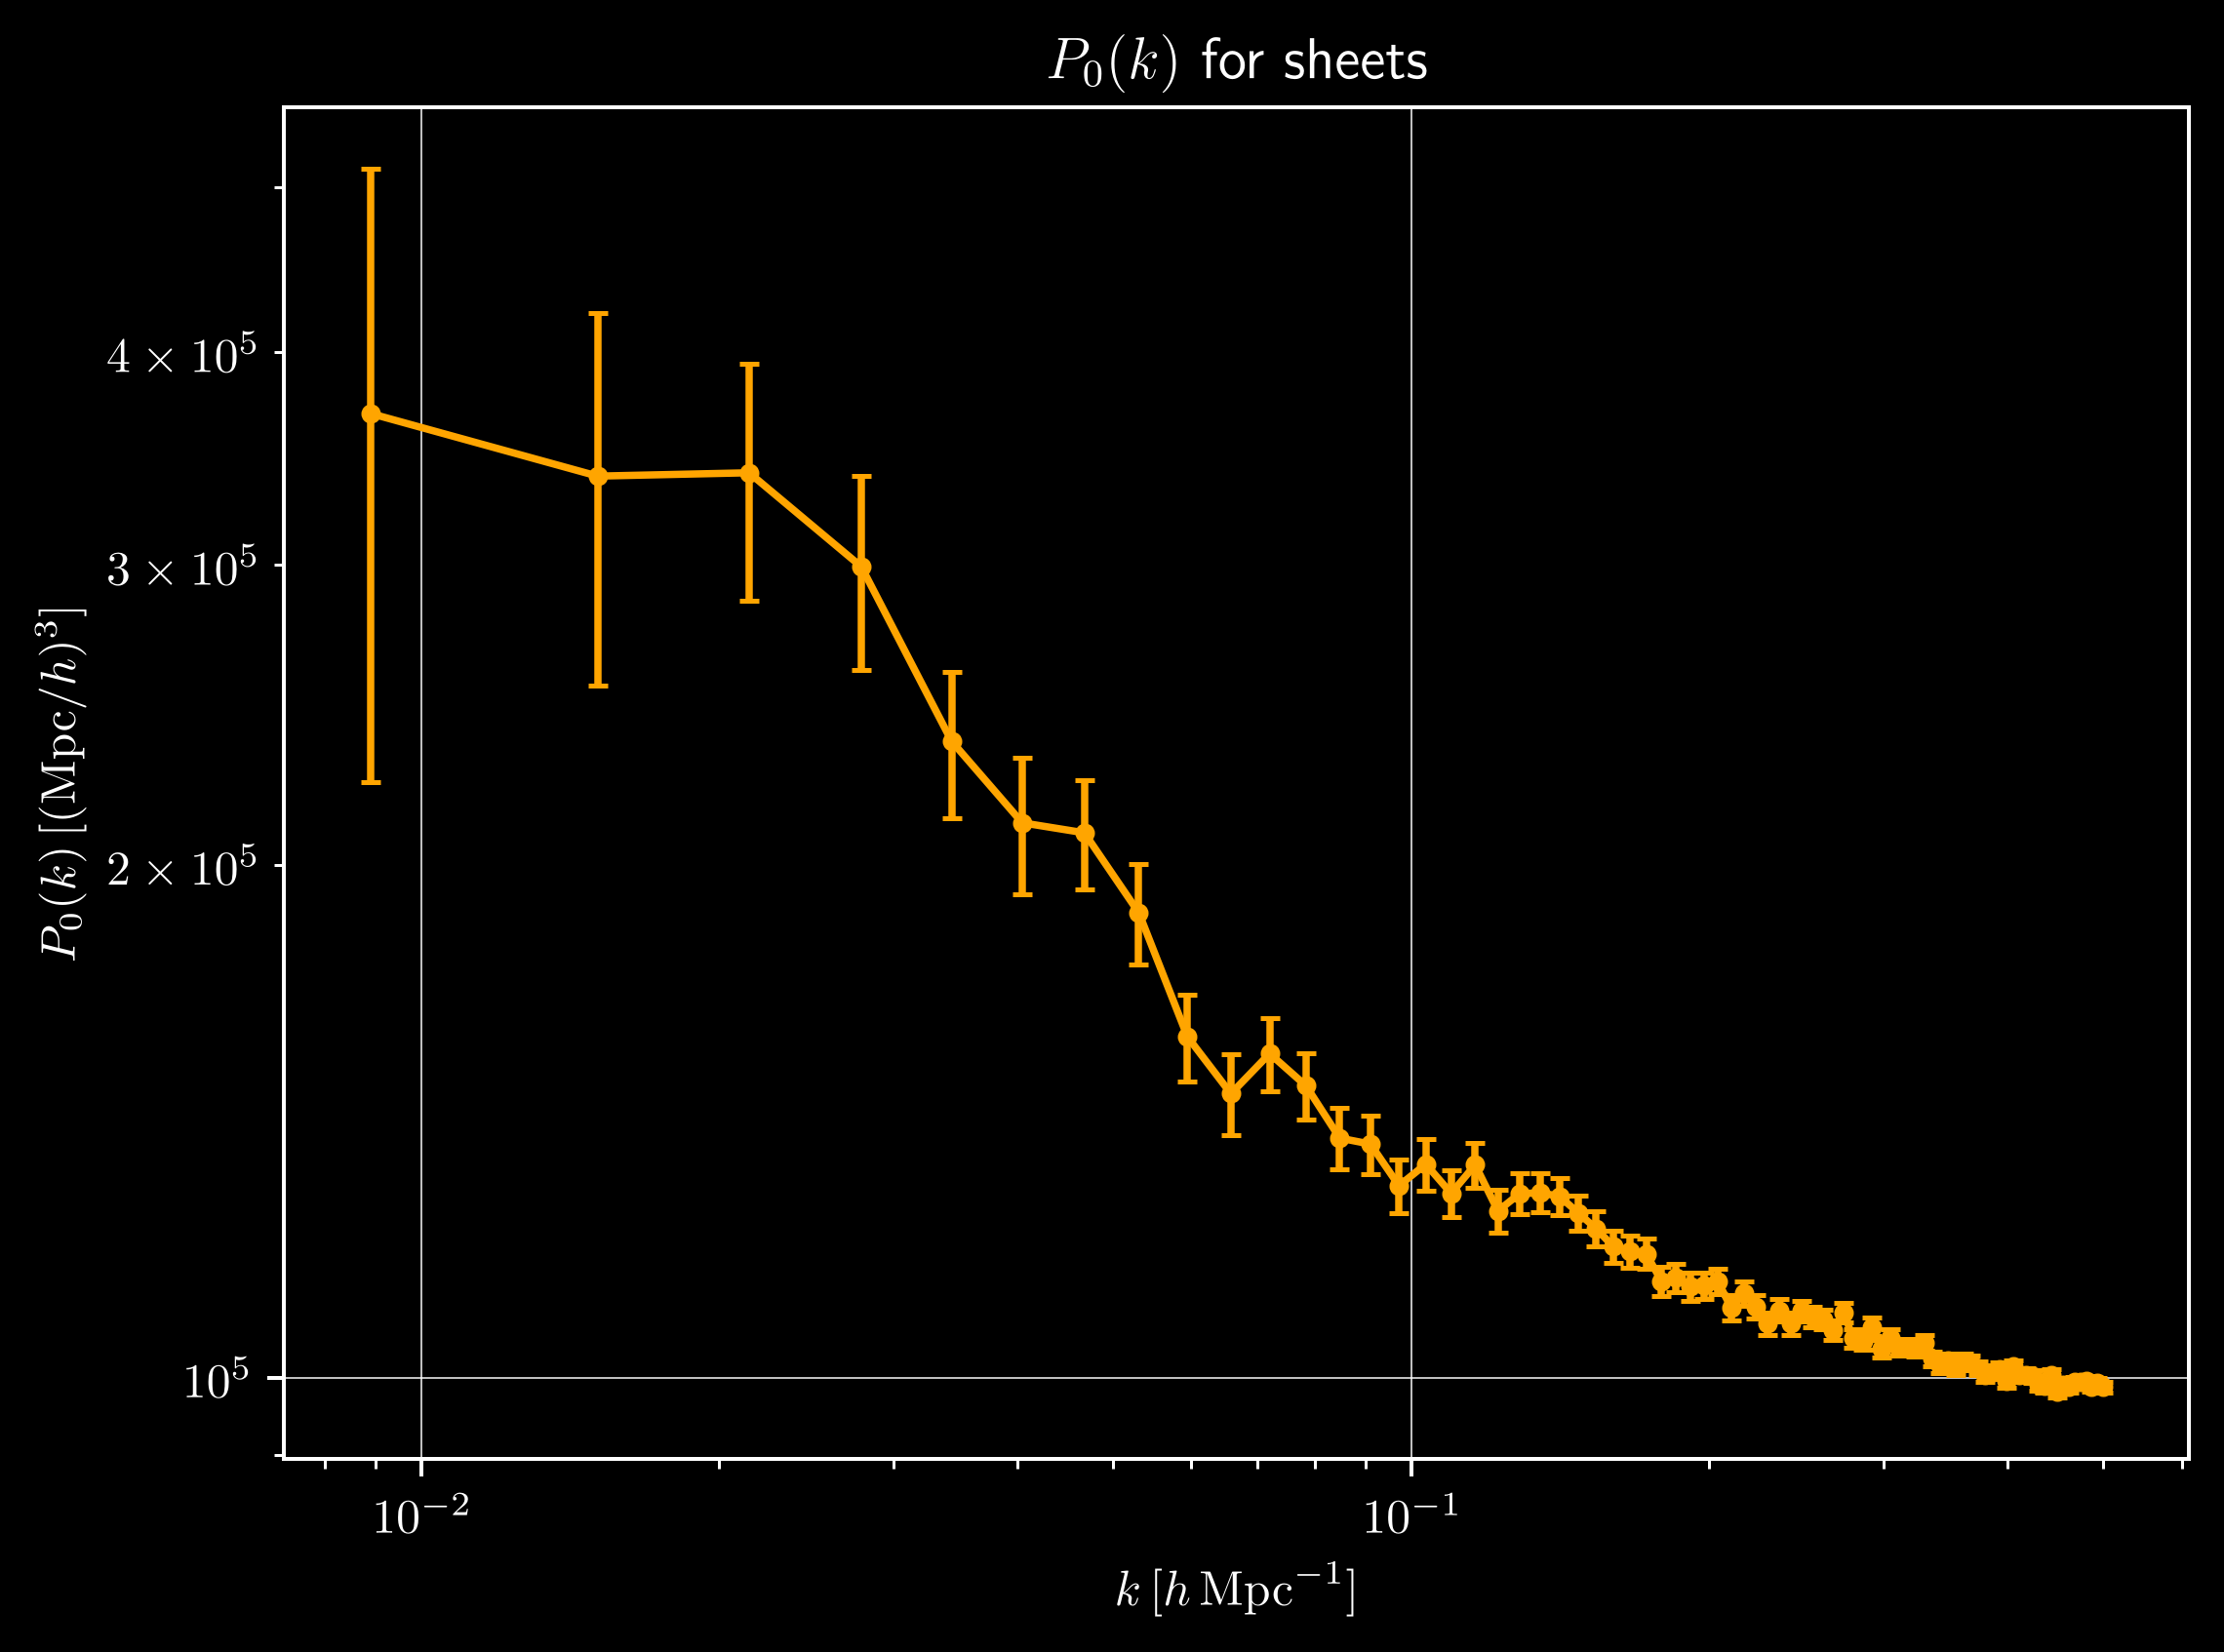

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask], fmt='.-',
            capsize=2, c='orange')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('$P_0(k)$ for sheets')

plt.show()

Filaments

In [25]:
pos = np.array([filaments['XCART'], filaments['YCART'], filaments['ZCART']]).astype(np.float32)
pos = np.ascontiguousarray(pos.T, dtype=np.float32)

In [26]:
grid = 512
MAS = 'CIC'
verbose = True

axis = 0
threads = 1
BoxSize = 1000.0

In [27]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))


Using CIC mass assignment scheme
Time taken = 0.053 seconds

-1.000 < delta < 44025.086
< delta > = -0.000


In [28]:
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

k = Pk.k3D
Pk0 = Pk.Pk[:,0]
Pkphase = Pk.Pkphase
Nmodes = Pk.Nmodes3D


Computing power spectrum of the field...
Time to complete loop = 8.16
Time taken = 12.81 seconds


In [29]:
sigma_P = Pk0 * np.sqrt(2.0 / Nmodes)

mask = (np.isfinite(k) & np.isfinite(Pk0) & np.isfinite(sigma_P)
        & (Nmodes > 0) & (k >= 0.008) & (k <= 0.5))

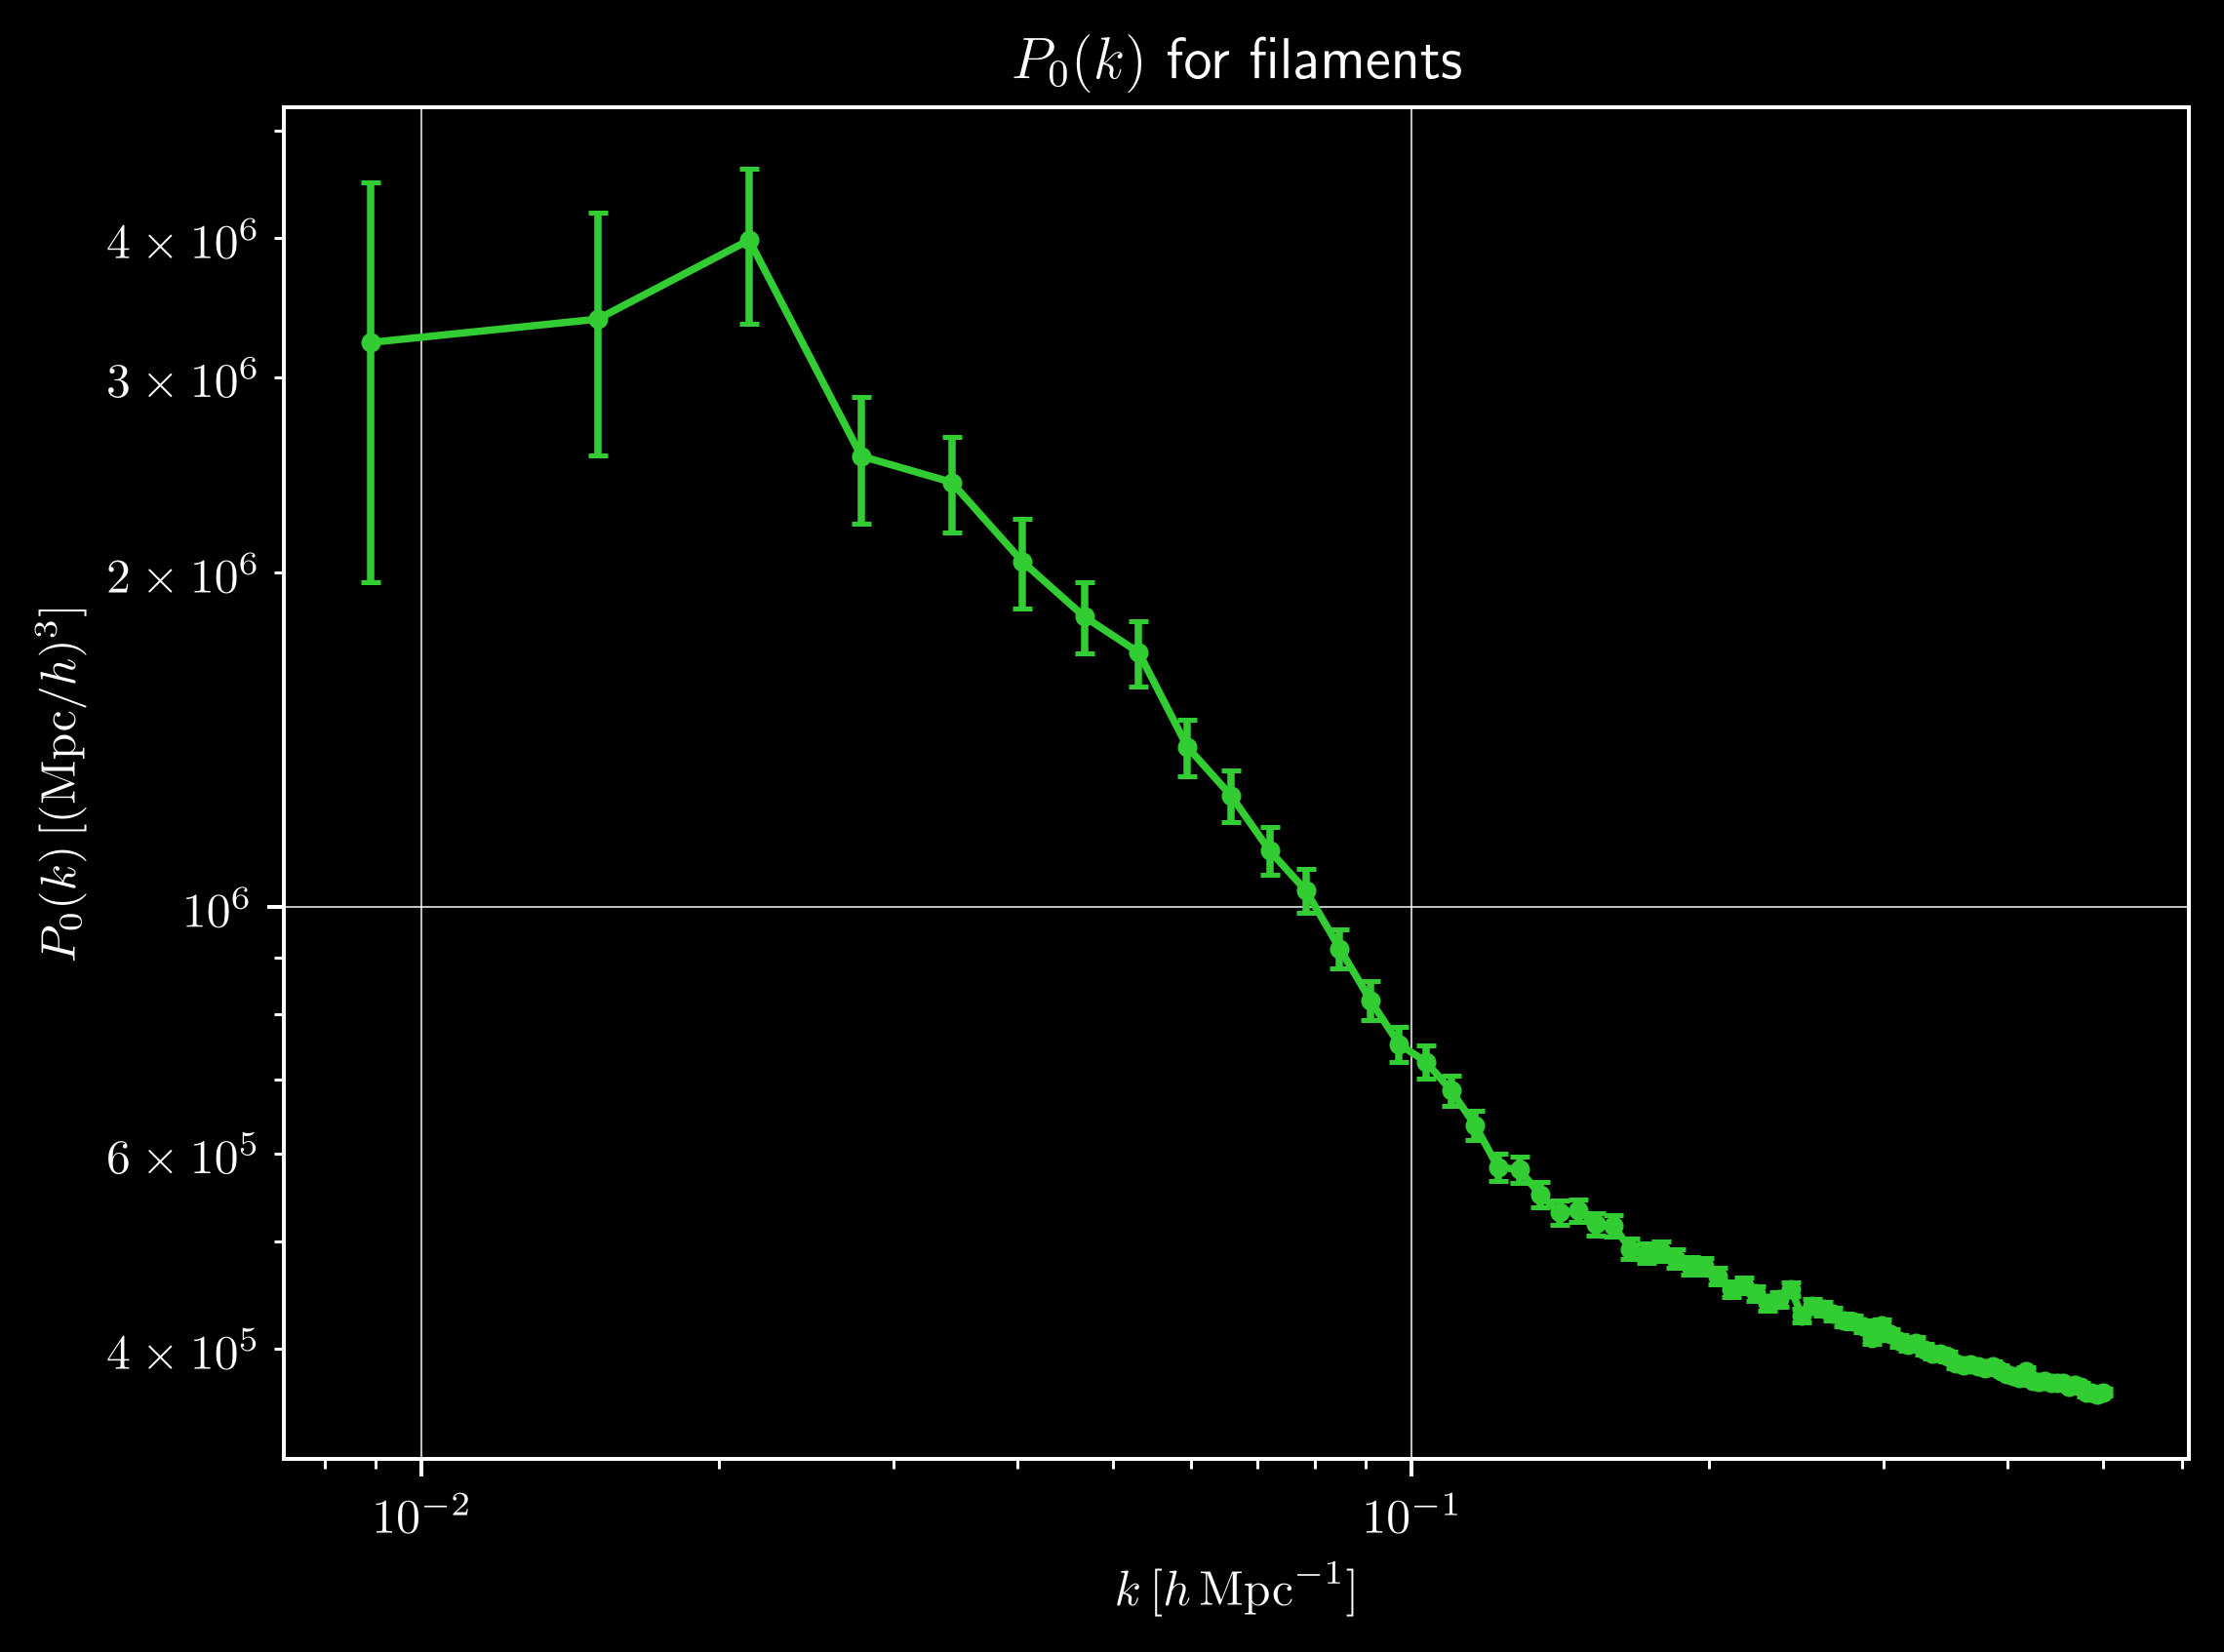

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask], fmt='.-',
            capsize=2, c='limegreen')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('$P_0(k)$ for filaments')

plt.show()

Knots

In [31]:
pos = np.array([knots['XCART'], knots['YCART'], knots['ZCART']]).astype(np.float32)
pos = np.ascontiguousarray(pos.T, dtype=np.float32)

In [32]:
grid = 512
MAS = 'CIC'
verbose = True

axis = 0
threads = 1
BoxSize = 1000.0

In [33]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))


Using CIC mass assignment scheme
Time taken = 0.001 seconds

-1.000 < delta < 914040.000
< delta > = 0.000


In [34]:
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

k = Pk.k3D
Pk0 = Pk.Pk[:,0]
Pkphase = Pk.Pkphase
Nmodes = Pk.Nmodes3D


Computing power spectrum of the field...
Time to complete loop = 8.22
Time taken = 12.93 seconds


In [35]:
sigma_P = Pk0 * np.sqrt(2.0 / Nmodes)

mask = (np.isfinite(k) & np.isfinite(Pk0) & np.isfinite(sigma_P)
        & (Nmodes > 0) & (k >= 0.008) & (k <= 0.5))

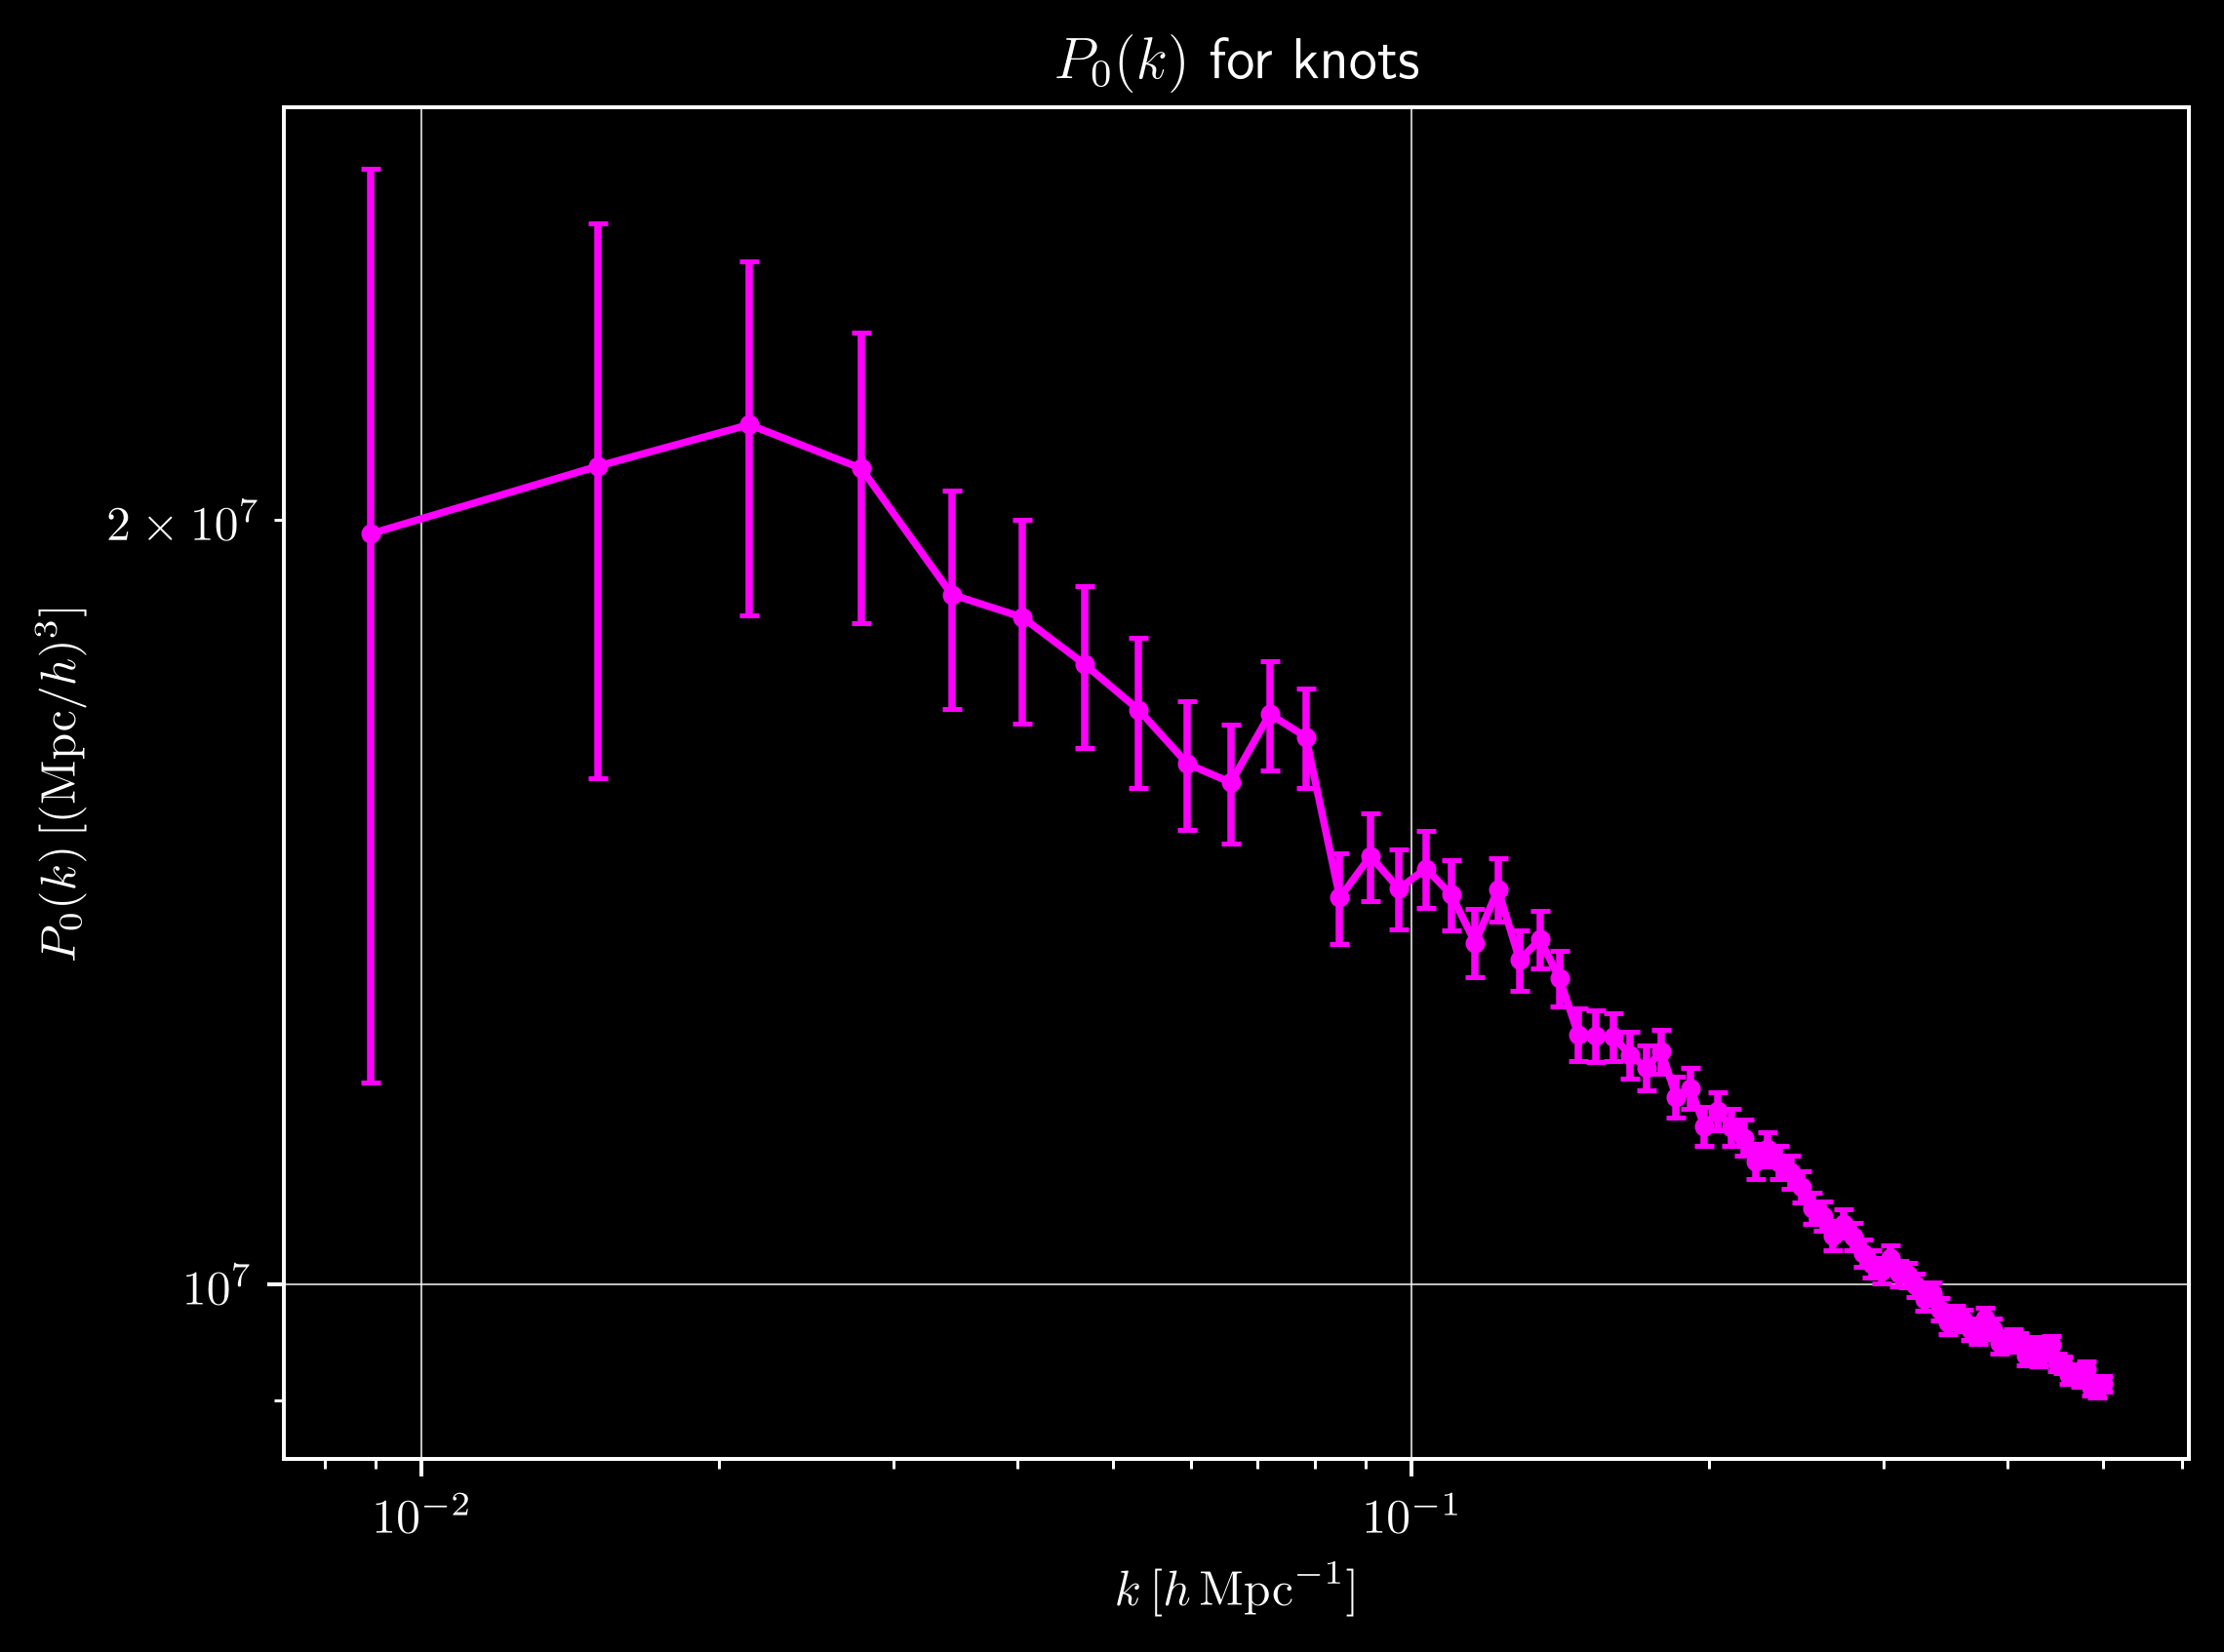

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask], fmt='.-',
            capsize=2, c='magenta')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('$P_0(k)$ for knots')

plt.show()

Comb

In [37]:
pos_v = np.array([voids['XCART'], voids['YCART'], voids['ZCART']]).astype(np.float32)
pos_v = np.ascontiguousarray(pos_v.T, dtype=np.float32)

pos_s = np.array([sheets['XCART'], sheets['YCART'], sheets['ZCART']]).astype(np.float32)
pos_s = np.ascontiguousarray(pos_s.T, dtype=np.float32)

pos_f = np.array([filaments['XCART'], filaments['YCART'], filaments['ZCART']]).astype(np.float32)
pos_f = np.ascontiguousarray(pos_f.T, dtype=np.float32)

pos_k = np.array([knots['XCART'], knots['YCART'], knots['ZCART']]).astype(np.float32)
pos_k = np.ascontiguousarray(pos_k.T, dtype=np.float32)

In [38]:
MAS_v = 'CIC'
delta_v = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_v, delta_v, BoxSize, MAS_v, verbose=verbose)
delta_v /= np.mean(delta_v, dtype=np.float64);  delta_v -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta_v), np.max(delta_v)))
print('< delta > = %.3f'%np.mean(delta_v))

Pk_v = PKL.Pk(delta_v, BoxSize, axis, MAS_v, threads, verbose)

k_v = Pk_v.k3D
Pk0_v = Pk_v.Pk[:,0]
Pkphase_v = Pk_v.Pkphase
Nmodes_v = Pk_v.Nmodes3D

sigma_P_v = Pk0_v * np.sqrt(2.0 / Nmodes_v)

mask_v = (np.isfinite(k_v) & np.isfinite(Pk0_v) & np.isfinite(sigma_P_v)
        & (Nmodes_v > 0) & (k_v >= 0.008) & (k_v <= 0.5))


Using CIC mass assignment scheme
Time taken = 0.020 seconds

-1.000 < delta < 58544.754
< delta > = -0.000

Computing power spectrum of the field...
Time to complete loop = 8.22
Time taken = 13.53 seconds


In [39]:
MAS_s = 'CIC'
delta_s = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_s, delta_s, BoxSize, MAS_s, verbose=verbose)
delta_s /= np.mean(delta_s, dtype=np.float64);  delta_s -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta_s), np.max(delta_s)))
print('< delta > = %.3f'%np.mean(delta_s))

Pk_s = PKL.Pk(delta_s, BoxSize, axis, MAS_s, threads, verbose)

k_s = Pk_s.k3D
Pk0_s = Pk_s.Pk[:,0]
Pkphase_s = Pk_s.Pkphase
Nmodes_s = Pk_s.Nmodes3D

sigma_P_s = Pk0_s * np.sqrt(2.0 / Nmodes_s)

mask_s = (np.isfinite(k_s) & np.isfinite(Pk0_s) & np.isfinite(sigma_P_s)
        & (Nmodes_s > 0) & (k_s >= 0.008) & (k_s <= 0.5))


Using CIC mass assignment scheme
Time taken = 0.108 seconds

-1.000 < delta < 12779.863
< delta > = -0.000

Computing power spectrum of the field...
Time to complete loop = 8.08
Time taken = 12.84 seconds


In [40]:
MAS_f = 'CIC'
delta_f = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_f, delta_f, BoxSize, MAS_f, verbose=verbose)
delta_f /= np.mean(delta_f, dtype=np.float64);  delta_f -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta_f), np.max(delta_f)))
print('< delta > = %.3f'%np.mean(delta_f))

Pk_f = PKL.Pk(delta_f, BoxSize, axis, MAS_f, threads, verbose)


k_f = Pk_f.k3D
Pk0_f = Pk_f.Pk[:,0]
Pkphase_f = Pk_f.Pkphase
Nmodes_f = Pk_f.Nmodes3D

sigma_P_f = Pk0_f * np.sqrt(2.0 / Nmodes_f)

mask_f = (np.isfinite(k_f) & np.isfinite(Pk0_f) & np.isfinite(sigma_P_f)
        & (Nmodes_f > 0) & (k_f >= 0.008) & (k_f <= 0.5))


Using CIC mass assignment scheme
Time taken = 0.022 seconds

-1.000 < delta < 44025.086
< delta > = -0.000

Computing power spectrum of the field...
Time to complete loop = 8.23
Time taken = 12.89 seconds


In [41]:
MAS_k = 'CIC'
delta_k = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_k, delta_k, BoxSize, MAS_k, verbose=verbose)
delta_k /= np.mean(delta_k, dtype=np.float64);  delta_k -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta_k), np.max(delta_k)))
print('< delta > = %.3f'%np.mean(delta_k))

Pk_k = PKL.Pk(delta_k, BoxSize, axis, MAS_k, threads, verbose)

k_k = Pk_k.k3D
Pk0_k = Pk_k.Pk[:,0]
Pkphase_k = Pk_k.Pkphase
Nmodes_k = Pk_k.Nmodes3D

sigma_P_k = Pk0_k * np.sqrt(2.0 / Nmodes_k)

mask_k = (np.isfinite(k_k) & np.isfinite(Pk0_k) & np.isfinite(sigma_P_k)
        & (Nmodes_k > 0) & (k_k >= 0.008) & (k_k <= 0.5))


Using CIC mass assignment scheme
Time taken = 0.001 seconds

-1.000 < delta < 914040.000
< delta > = 0.000

Computing power spectrum of the field...
Time to complete loop = 8.16
Time taken = 12.93 seconds


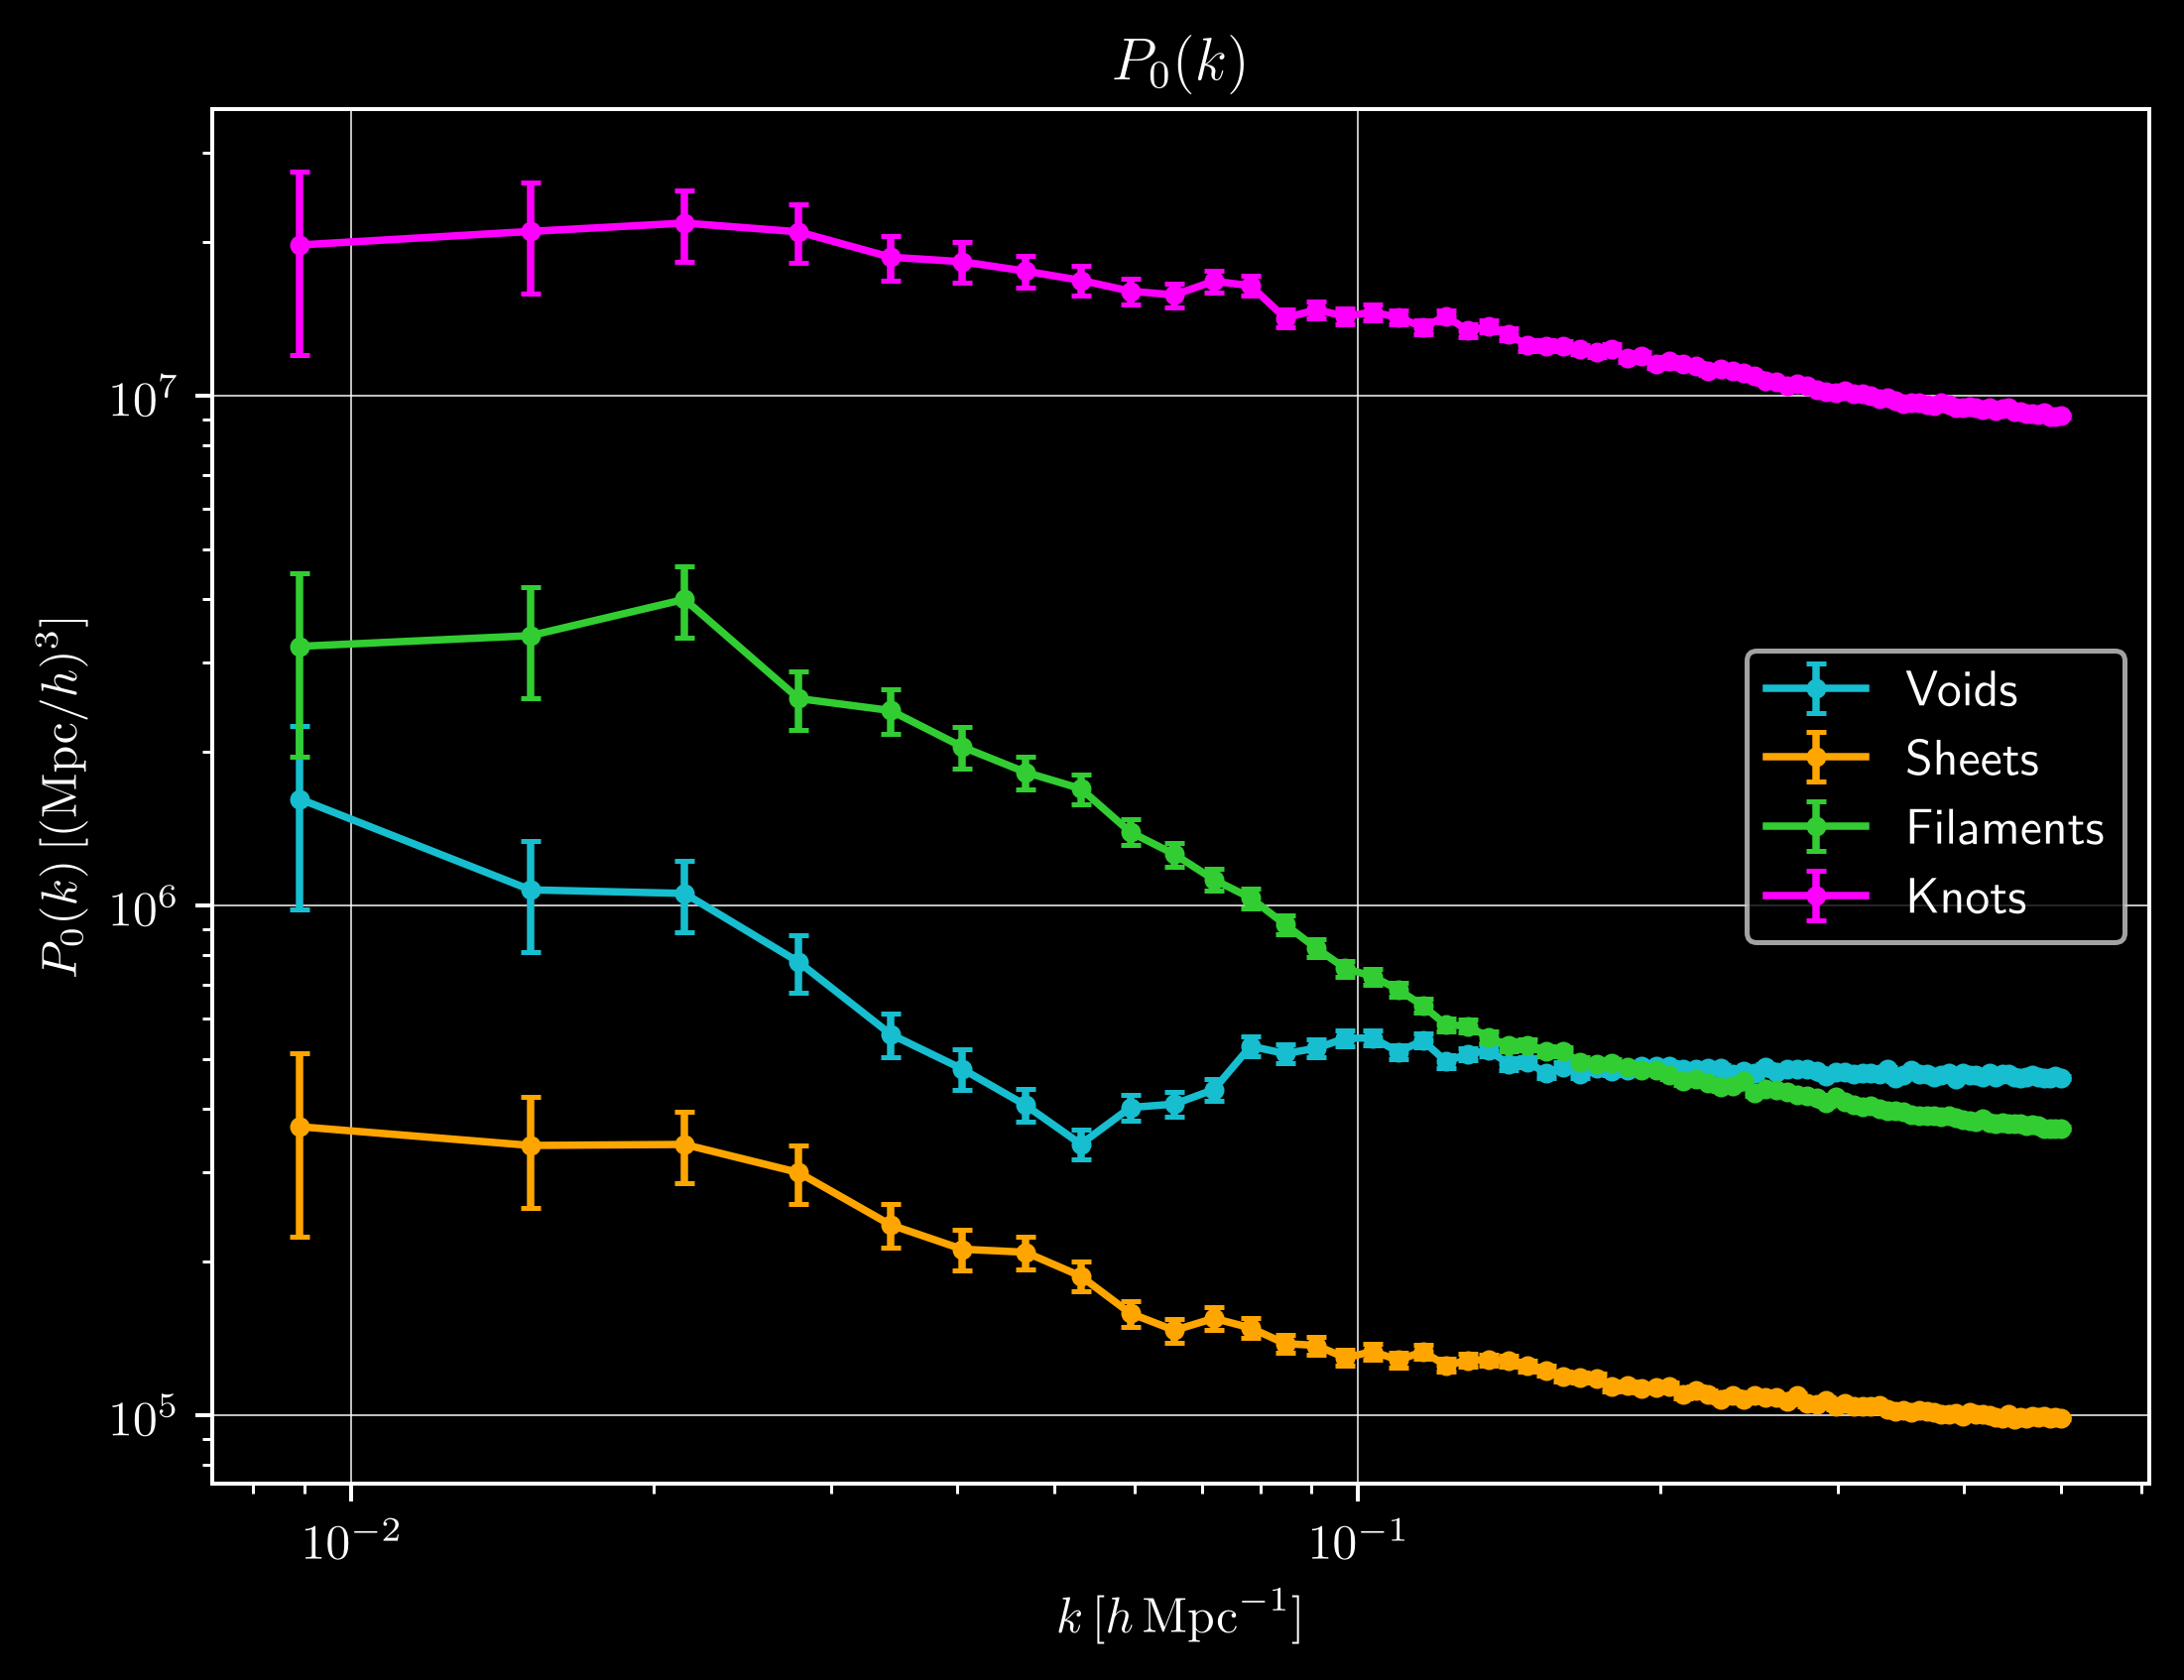

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k_v[mask_v], Pk0_v[mask_v], yerr=sigma_P_v[mask_v], fmt='.-',
            capsize=2, c='#17becf', label='Voids')
ax.errorbar(k_s[mask_s], Pk0_s[mask_s], yerr=sigma_P_s[mask_s], fmt='.-',
            capsize=2, c='orange', label='Sheets')
ax.errorbar(k_f[mask_f], Pk0_f[mask_f], yerr=sigma_P_f[mask_f], fmt='.-',
            capsize=2, c='limegreen', label='Filaments')
ax.errorbar(k_k[mask_k], Pk0_k[mask_k], yerr=sigma_P_k[mask_k], fmt='.-',
            capsize=2, c='magenta', label='Knots')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('$P_0(k)$')
plt.legend()

plt.show()

In [43]:
pos = np.column_stack([real_data['XCART'], real_data['YCART'], real_data['ZCART']]).astype(np.float32)
pos = np.ascontiguousarray(pos, dtype=np.float32)

In [44]:
MAS = 'CIC'
delta = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))

Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

k = Pk.k3D
Pk0 = Pk.Pk[:,0]
Pkphase = Pk.Pkphase
Nmodes = Pk.Nmodes3D

sigma_P = Pk0 * np.sqrt(2.0 / Nmodes)

mask = (np.isfinite(k) & np.isfinite(Pk0) & np.isfinite(sigma_P)
        & (Nmodes > 0) & (k >= 0.008) & (k <= 0.5))


Using CIC mass assignment scheme
Time taken = 0.127 seconds

-1.000 < delta < 8540.422
< delta > = -0.000

Computing power spectrum of the field...
Time to complete loop = 8.17
Time taken = 13.04 seconds


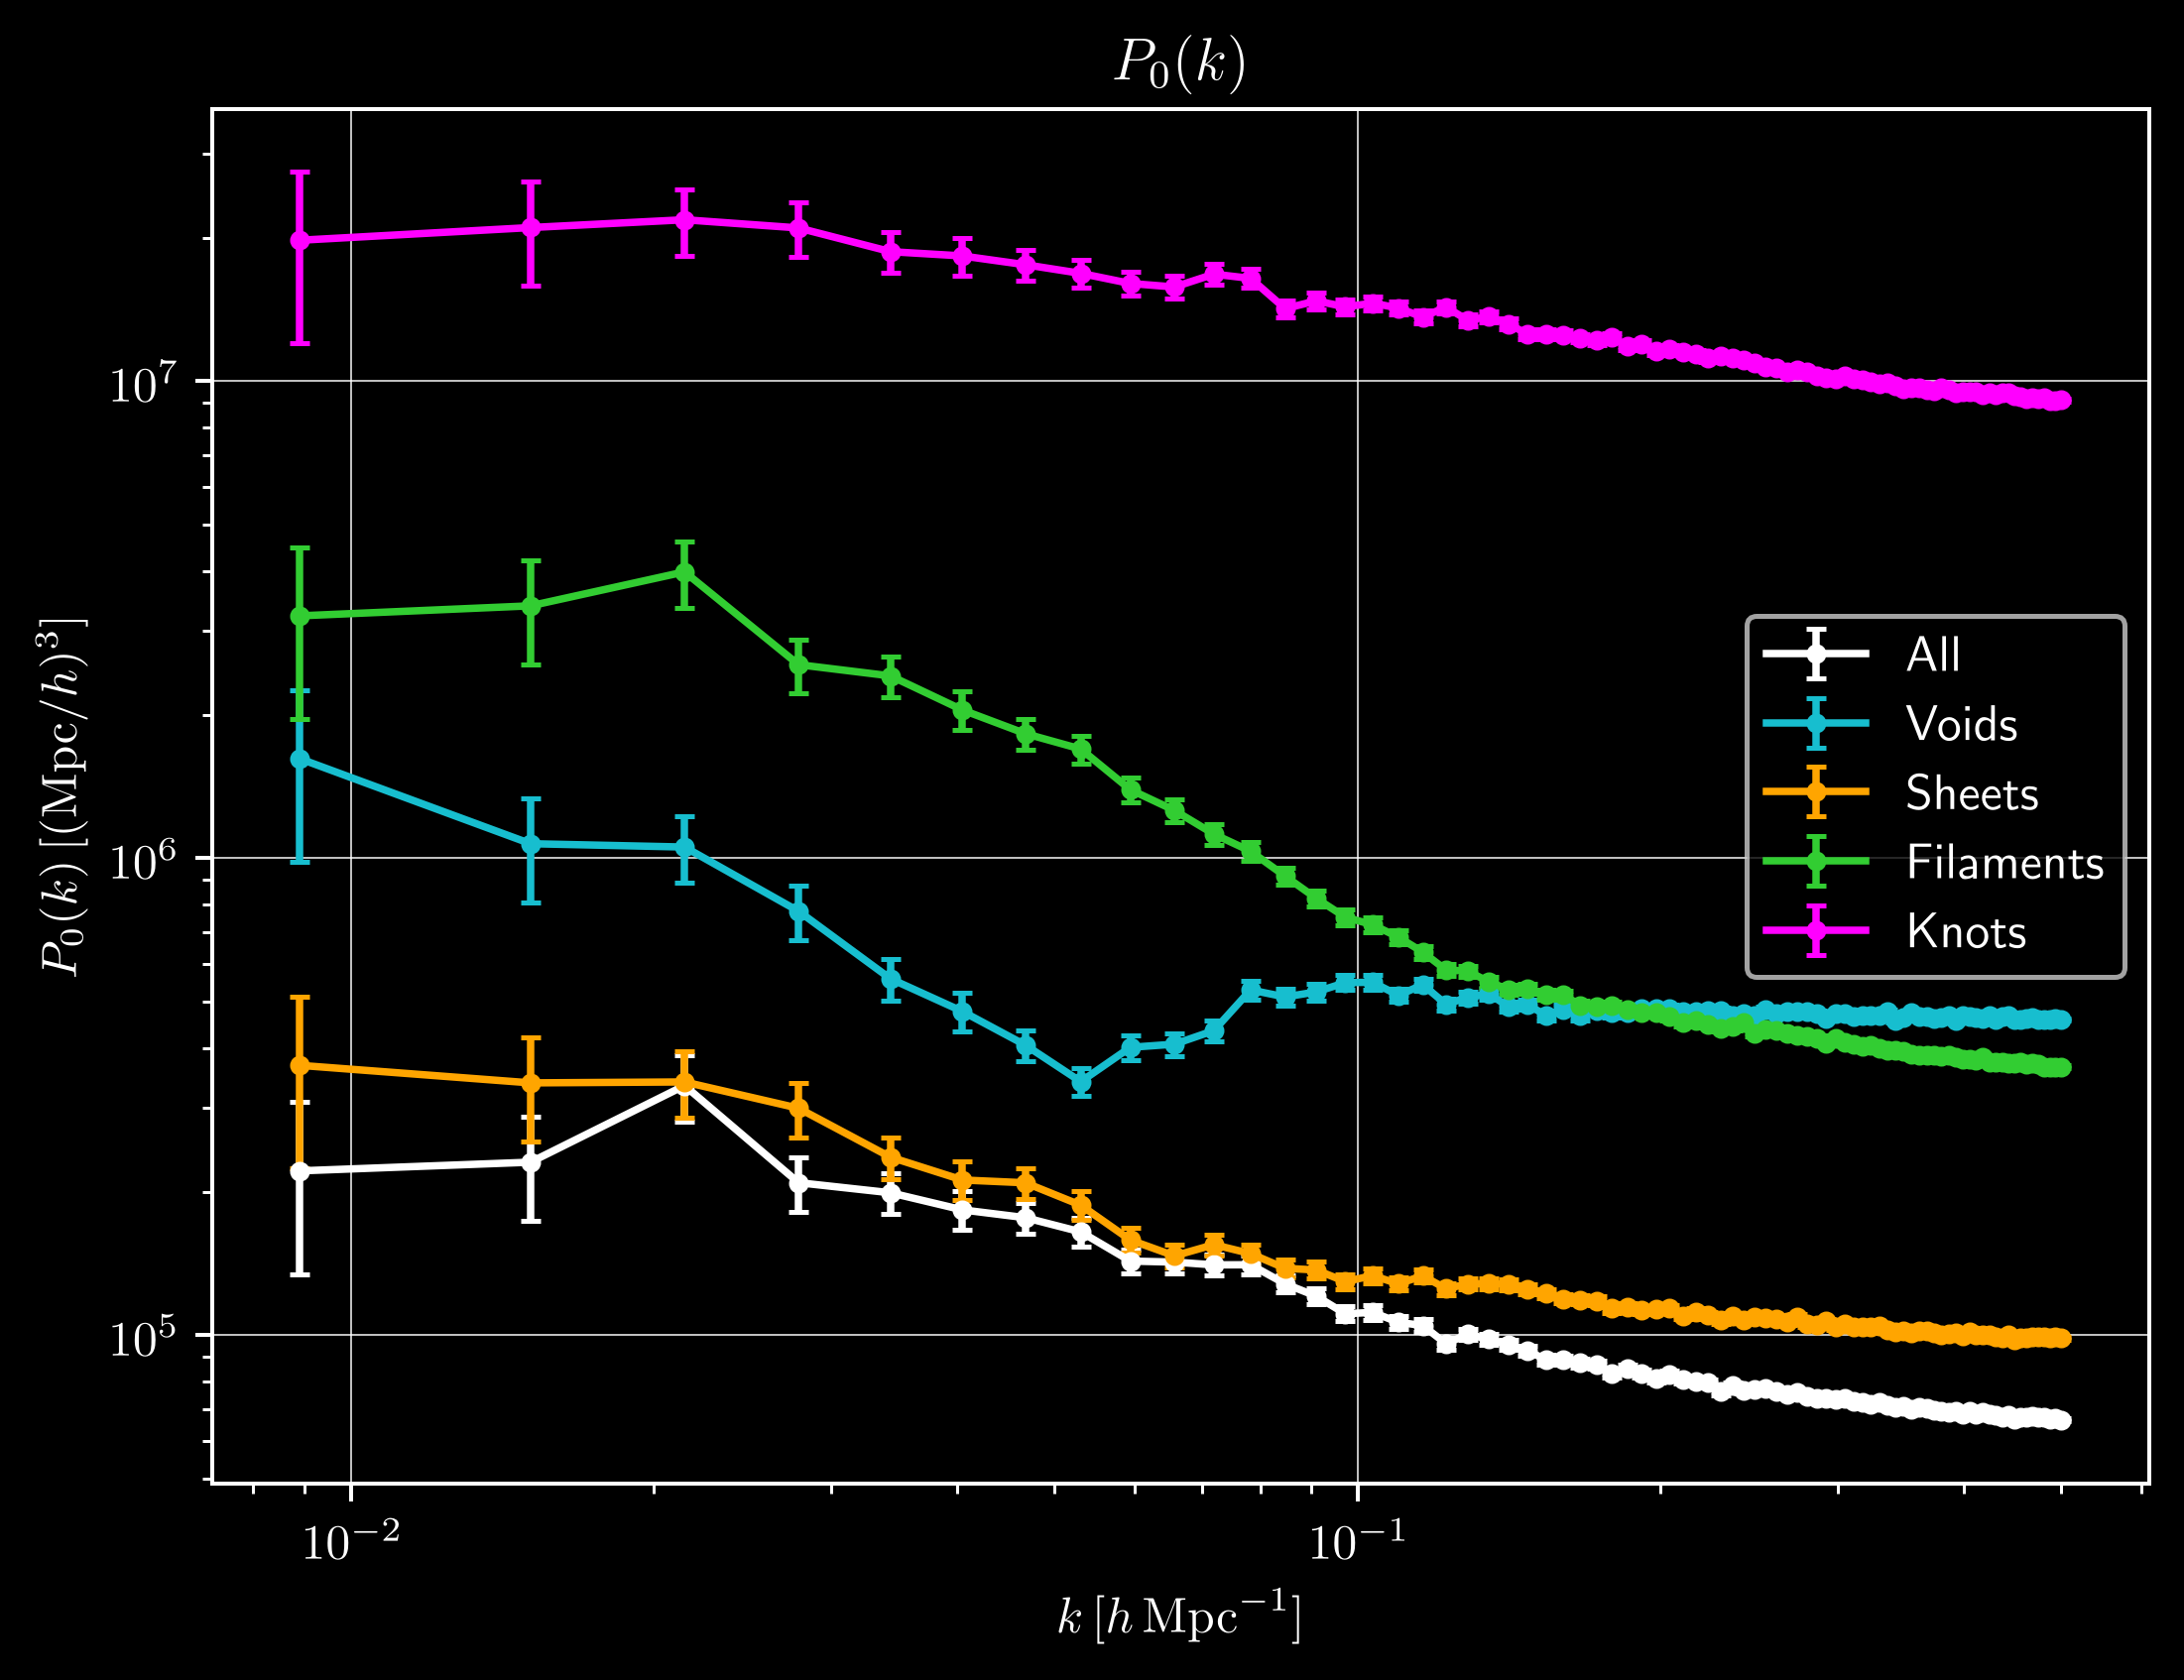

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask], fmt='.-',
            capsize=2, c='white', label='All')

ax.errorbar(k_v[mask_v], Pk0_v[mask_v], yerr=sigma_P_v[mask_v], fmt='.-',
            capsize=2, c='#17becf', label='Voids')
ax.errorbar(k_s[mask_s], Pk0_s[mask_s], yerr=sigma_P_s[mask_s], fmt='.-',
            capsize=2, c='orange', label='Sheets')
ax.errorbar(k_f[mask_f], Pk0_f[mask_f], yerr=sigma_P_f[mask_f], fmt='.-',
            capsize=2, c='limegreen', label='Filaments')
ax.errorbar(k_k[mask_k], Pk0_k[mask_k], yerr=sigma_P_k[mask_k], fmt='.-',
            capsize=2, c='magenta', label='Knots')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('$P_0(k)$')
plt.legend()

plt.show()

In [49]:
volume = BoxSize**3

Pshot_all = volume / len(pos)
Pshot_void = volume / len(pos_v)
Pshot_sheet = volume / len(pos_s)
Pshot_filament = volume / len(pos_f)
Pshot_knot = volume / len(pos_k)

print('Pshot all =', Pshot_all)
print('Pshot voids =', Pshot_void)
print('Pshot sheets =', Pshot_sheet)
print('Pshot filaments =', Pshot_filament)
print('Pshot knots =', Pshot_knot)

Pshot all = 64383.20885912954
Pshot voids = 455580.86560364463
Pshot sheets = 96339.11368015414
Pshot filaments = 352236.7030644593
Pshot knots = 8474576.271186441


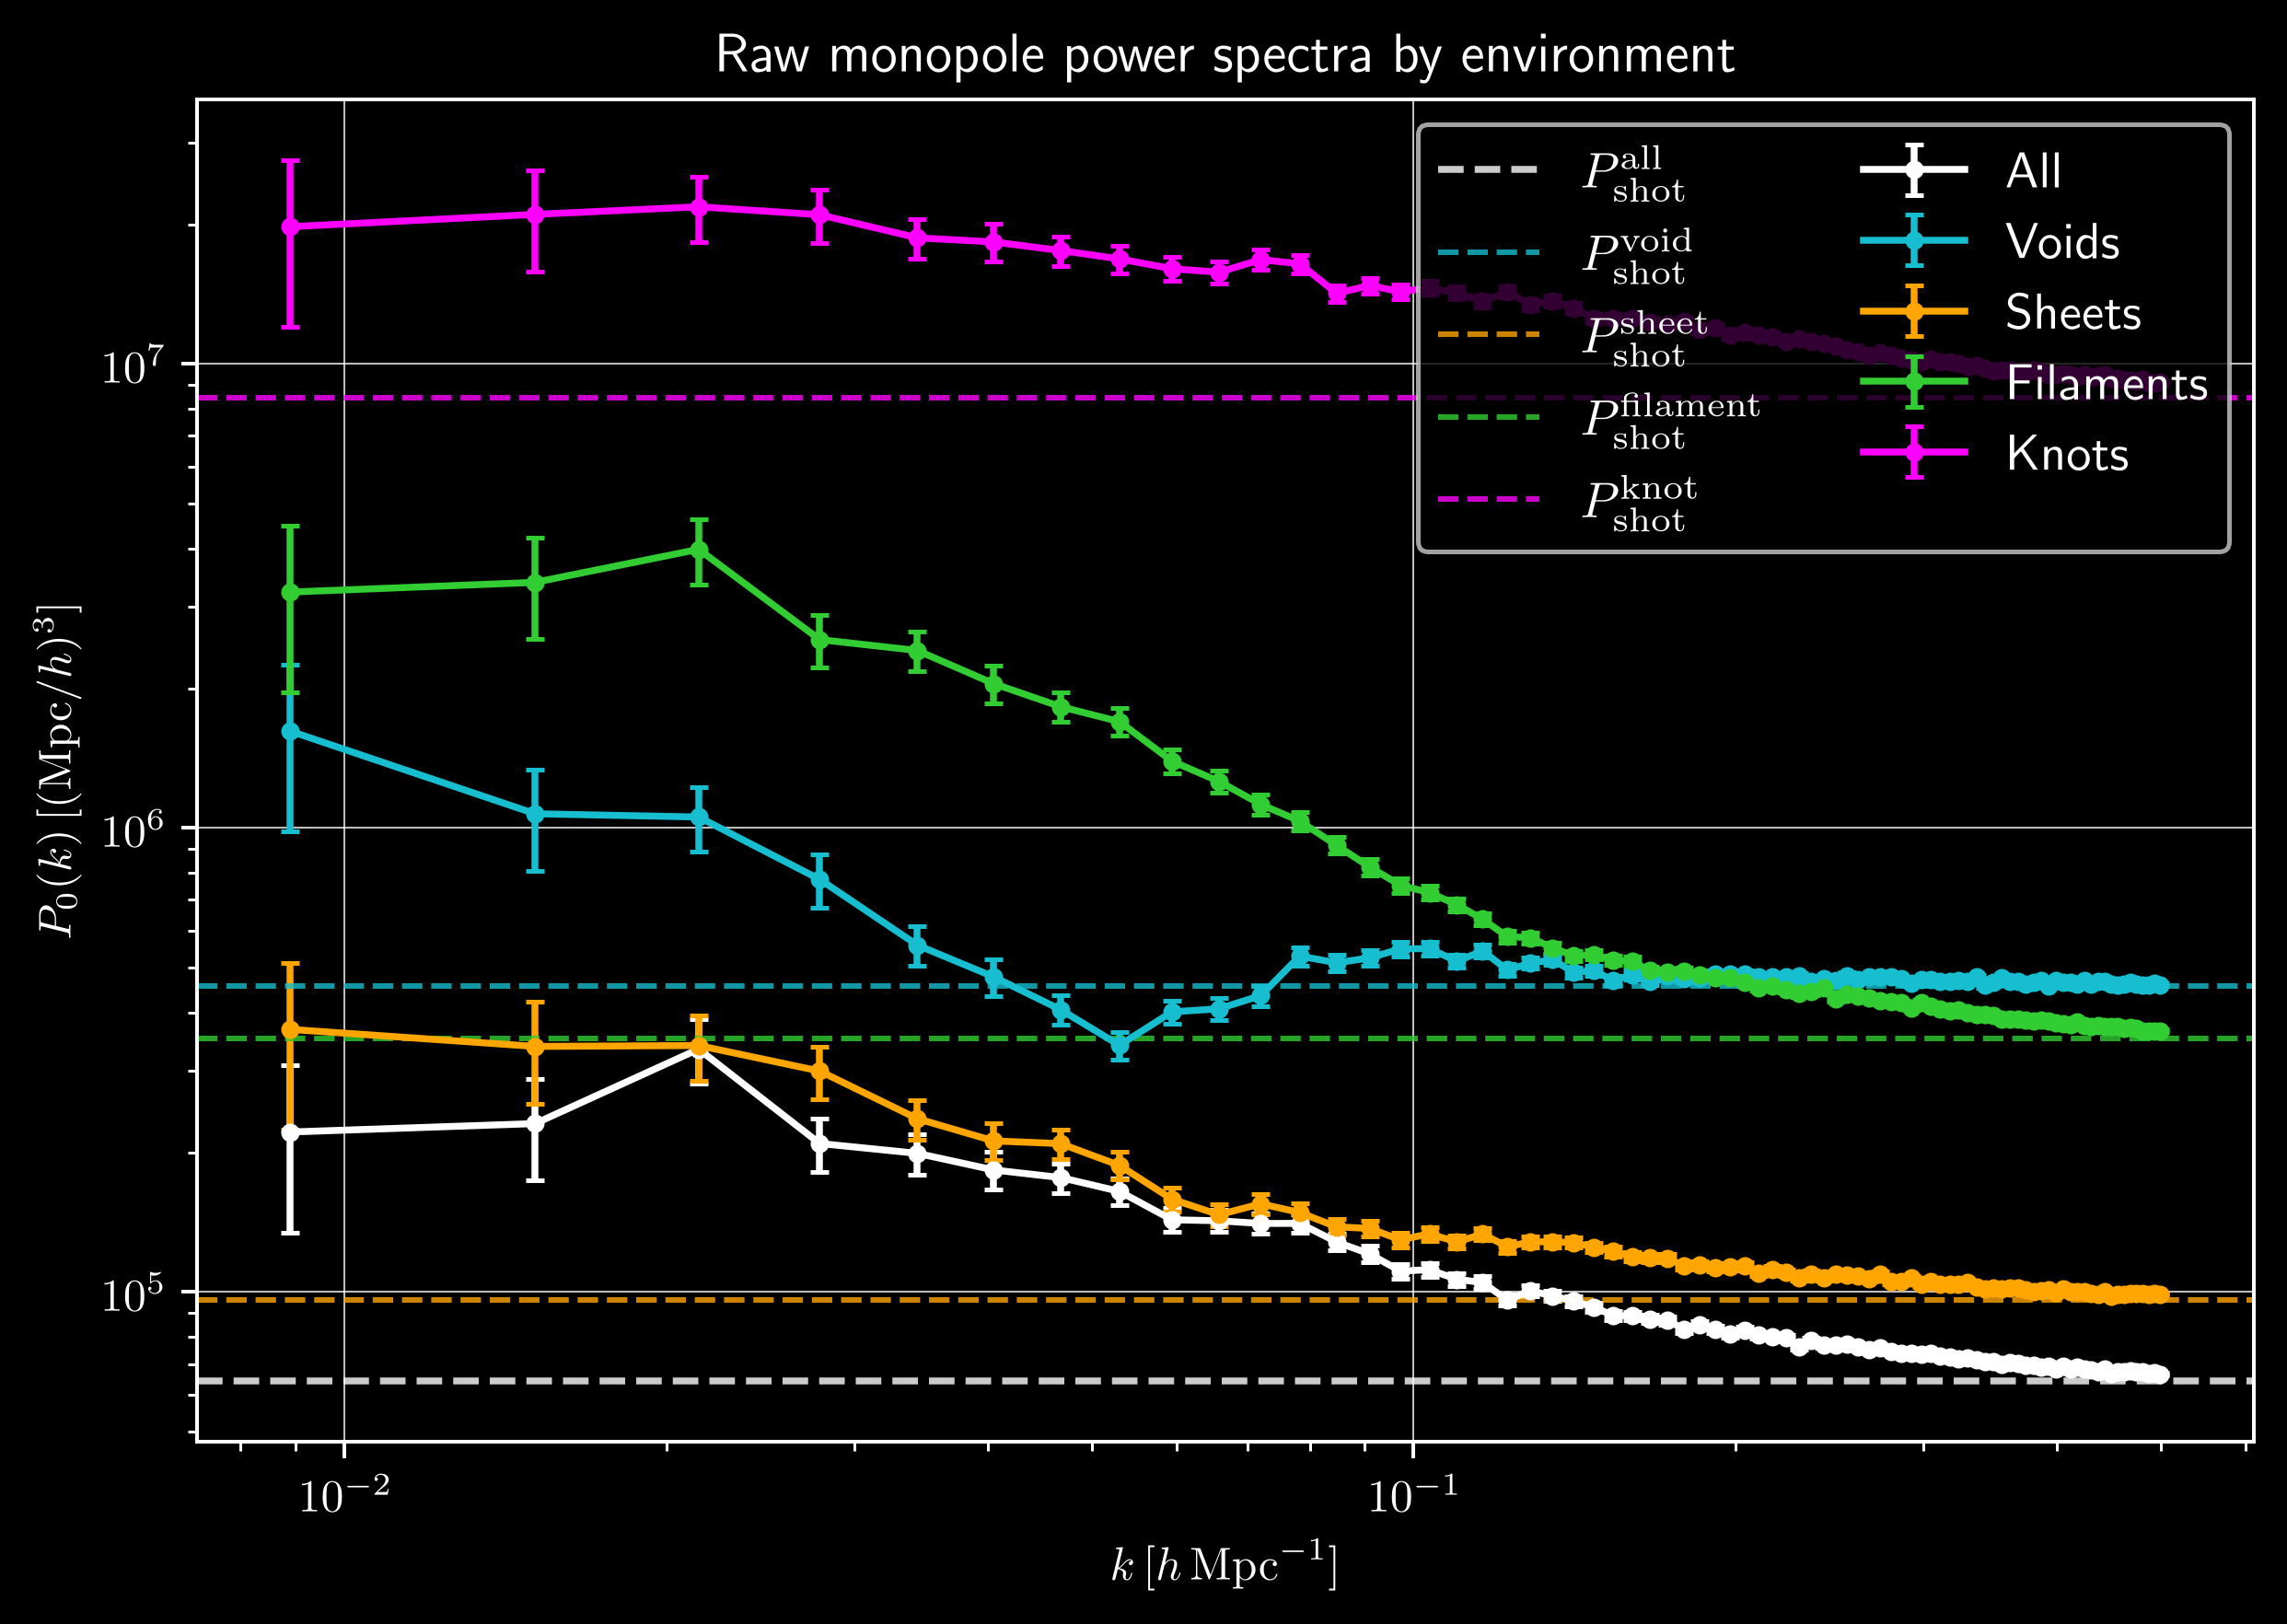

In [61]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask],
            fmt='.-', capsize=2, c='white', label='All')
ax.errorbar(k_v[mask_v], Pk0_v[mask_v], yerr=sigma_P_v[mask_v],
            fmt='.-', capsize=2, c='#17becf', label='Voids')
ax.errorbar(k_s[mask_s], Pk0_s[mask_s], yerr=sigma_P_s[mask_s],
            fmt='.-', capsize=2, c='orange', label='Sheets')
ax.errorbar(k_f[mask_f], Pk0_f[mask_f], yerr=sigma_P_f[mask_f],
            fmt='.-', capsize=2, c='limegreen', label='Filaments')
ax.errorbar(k_k[mask_k], Pk0_k[mask_k], yerr=sigma_P_k[mask_k],
            fmt='.-', capsize=2, c='magenta', label='Knots')

ax.axhline(Pshot_all, color='white', ls='--', lw=1.5, alpha=0.8,
           label=r'$P_{\rm shot}^{\rm all}$')
ax.axhline(Pshot_void, color='#17becf', ls='--', lw=1.2, alpha=0.8,
           label=r'$P_{\rm shot}^{\rm void}$')
ax.axhline(Pshot_sheet, color='orange', ls='--', lw=1.2, alpha=0.8,
           label=r'$P_{\rm shot}^{\rm sheet}$')
ax.axhline(Pshot_filament, color='limegreen', ls='--', lw=1.2, alpha=0.8,
           label=r'$P_{\rm shot}^{\rm filament}$')
ax.axhline(Pshot_knot, color='magenta', ls='--', lw=1.2, alpha=0.8,
           label=r'$P_{\rm shot}^{\rm knot}$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
ax.set_title(r'Raw monopole power spectra by environment')

ax.legend(fontsize=11, ncol=2, loc='upper right', framealpha=0.8)
plt.tight_layout()
plt.show()

In [54]:
Pk0_cl = Pk0 - Pshot_all
Pk0_v_cl = Pk0_v - Pshot_void
Pk0_s_cl = Pk0_s - Pshot_sheet
Pk0_f_cl = Pk0_f - Pshot_filament
Pk0_k_cl = Pk0_k - Pshot_knot

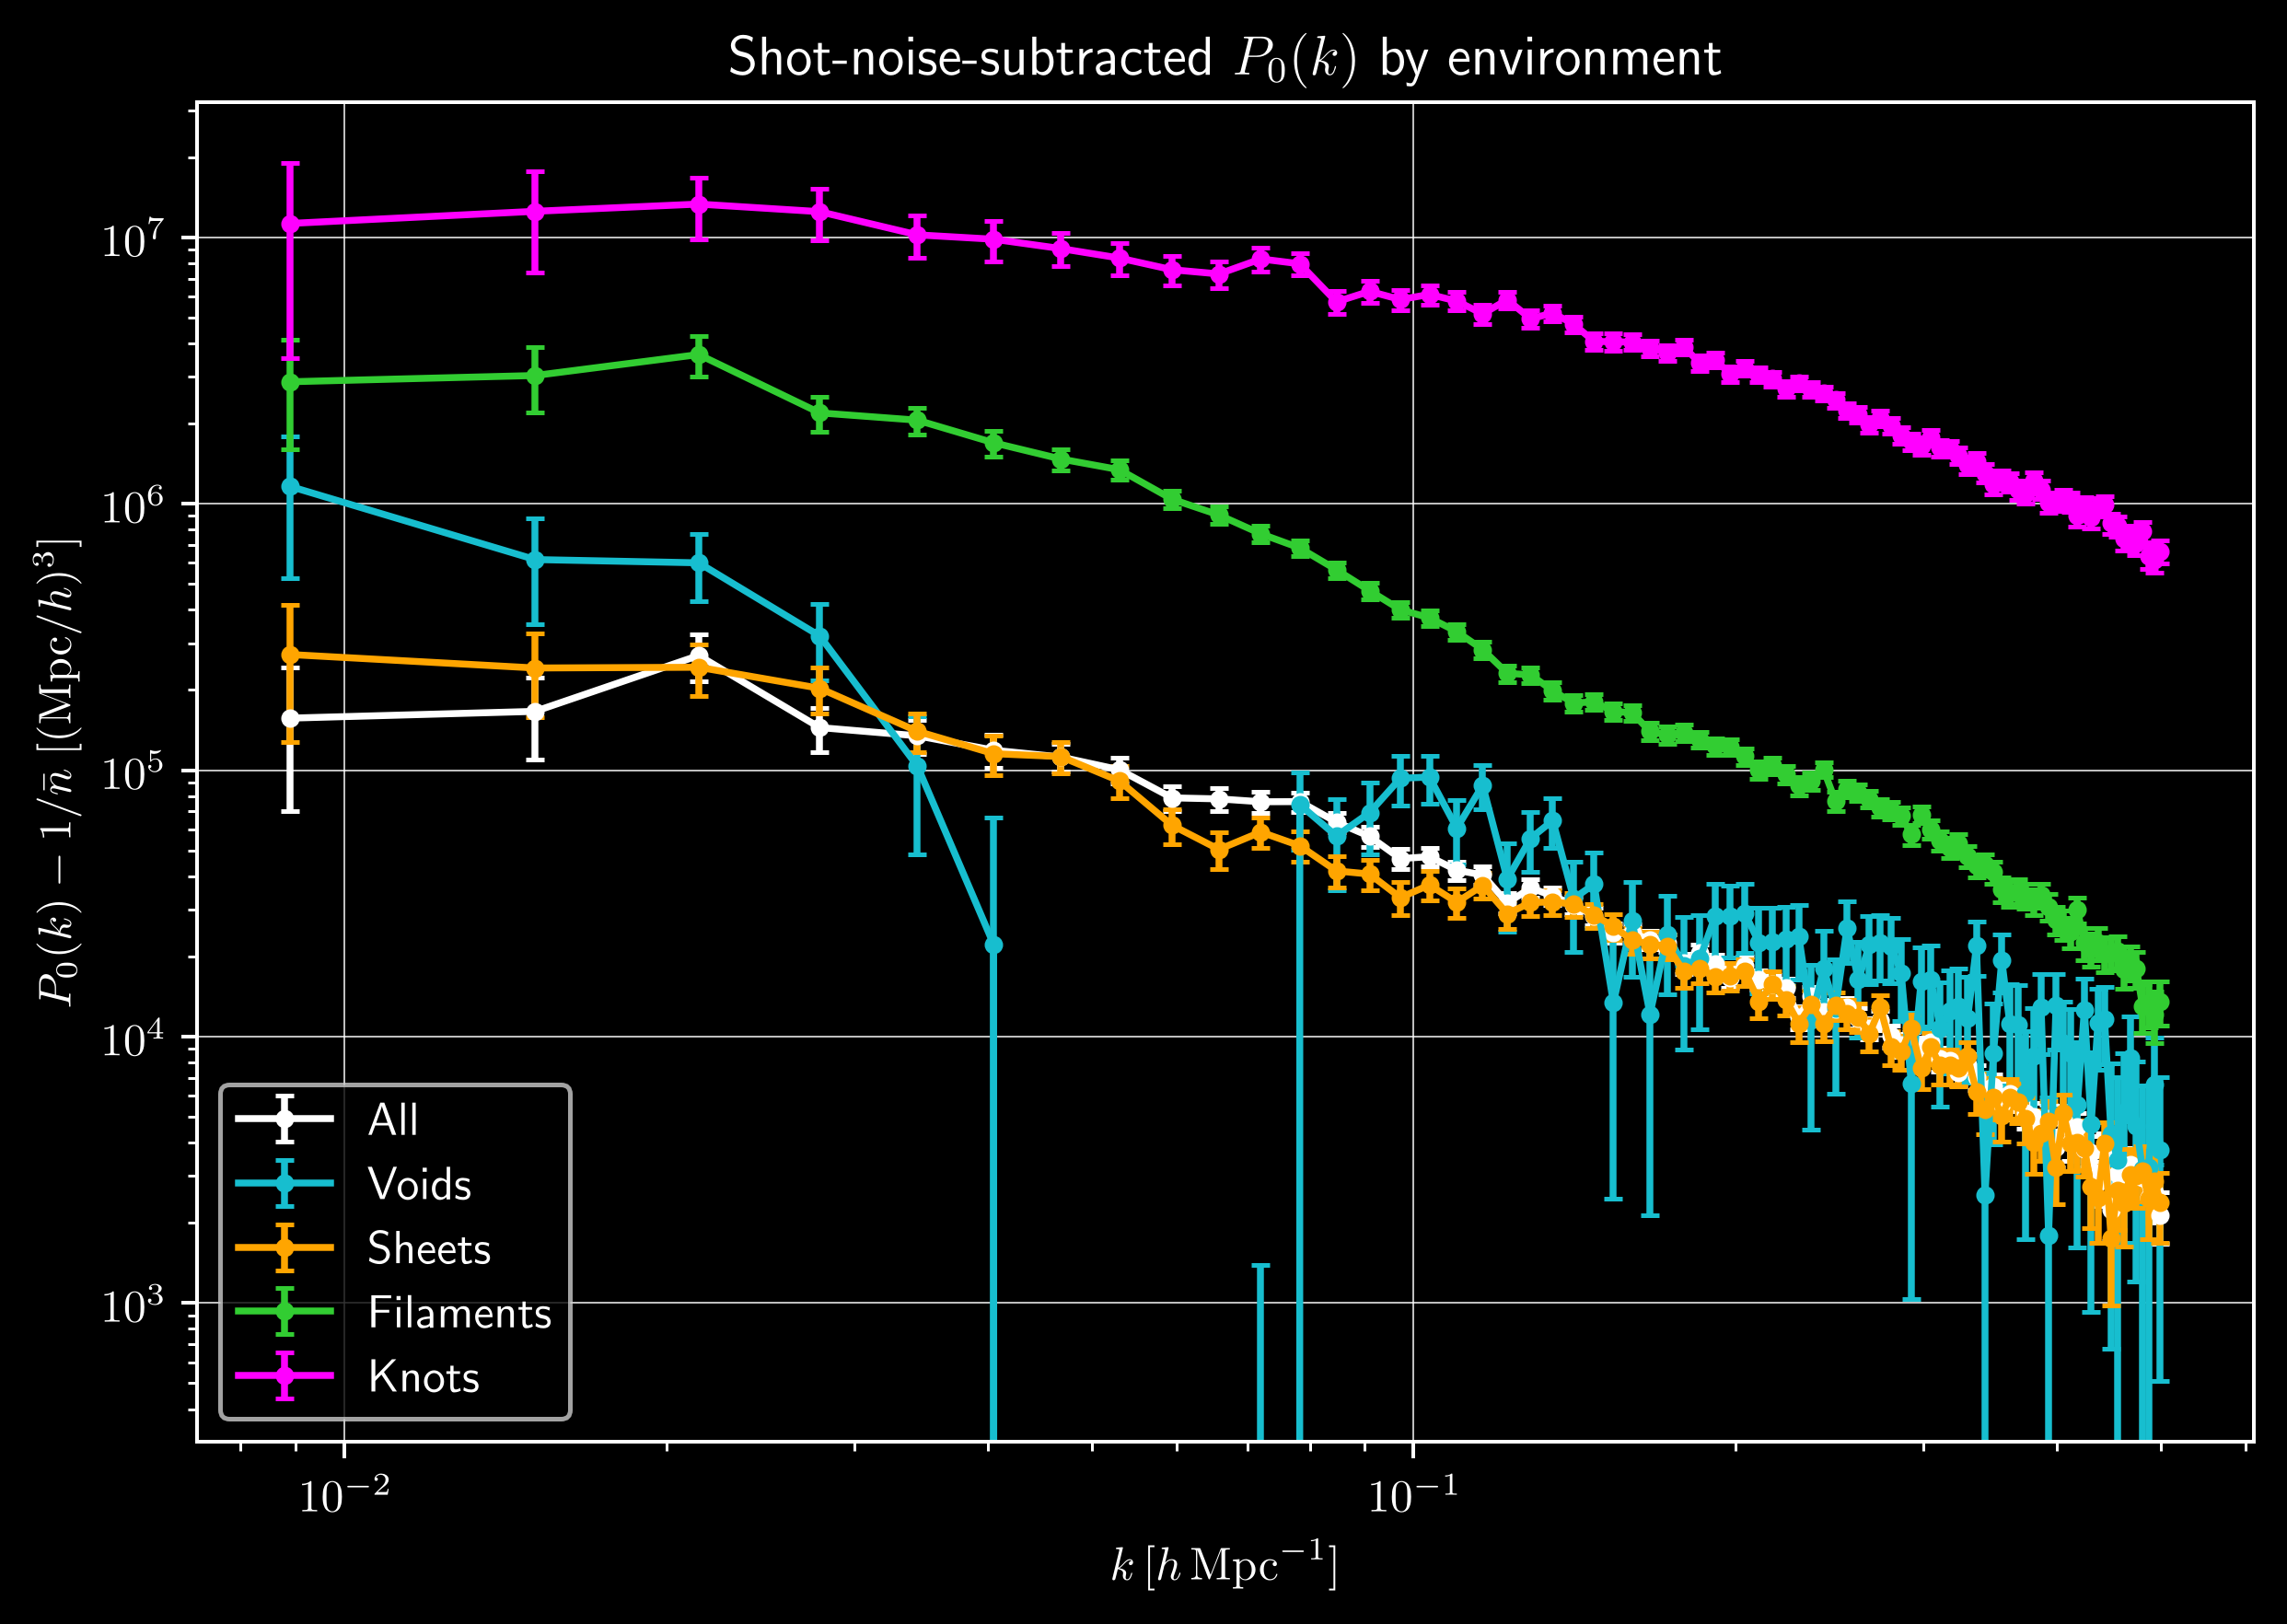

In [65]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.grid(lw=0.3)

ax.errorbar(k[mask], Pk0_cl[mask], yerr=sigma_P[mask],
            fmt='.-', capsize=2, c='white', label='All')

ax.errorbar(k_v[mask_v], Pk0_v_cl[mask_v], yerr=sigma_P_v[mask_v],
            fmt='.-', capsize=2, c='#17becf', label='Voids')

ax.errorbar(k_s[mask_s], Pk0_s_cl[mask_s], yerr=sigma_P_s[mask_s],
            fmt='.-', capsize=2, c='orange', label='Sheets')

ax.errorbar(k_f[mask_f], Pk0_f_cl[mask_f], yerr=sigma_P_f[mask_f],
            fmt='.-', capsize=2, c='limegreen', label='Filaments')

ax.errorbar(k_k[mask_k], Pk0_k_cl[mask_k], yerr=sigma_P_k[mask_k],
            fmt='.-', capsize=2, c='magenta', label='Knots')

# ax.axhline(0.0, color='gray', ls='--', lw=1)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)-1/\bar n\;[(\mathrm{Mpc}/h)^3]$')
ax.set_title(r'Shot-noise-subtracted $P_0(k)$ by environment')

ax.legend()
plt.tight_layout()
plt.show()

In [70]:
kmin = 0.008
kmax = 0.5

ratio_v = Pk0_v / Pk0
ratio_s = Pk0_s / Pk0
ratio_f = Pk0_f / Pk0
ratio_k = Pk0_k / Pk0

mask_ratio = (np.isfinite(k)
              & np.isfinite(Pk0)
              & np.isfinite(ratio_v)
              & np.isfinite(ratio_s)
              & np.isfinite(ratio_f)
              & np.isfinite(ratio_k)
              & (Pk0 > 0)
              & (ratio_v > 0)
              & (ratio_s > 0)
              & (ratio_f > 0)
              & (ratio_k > 0)
              & (k >= kmin)
              & (k <= kmax))

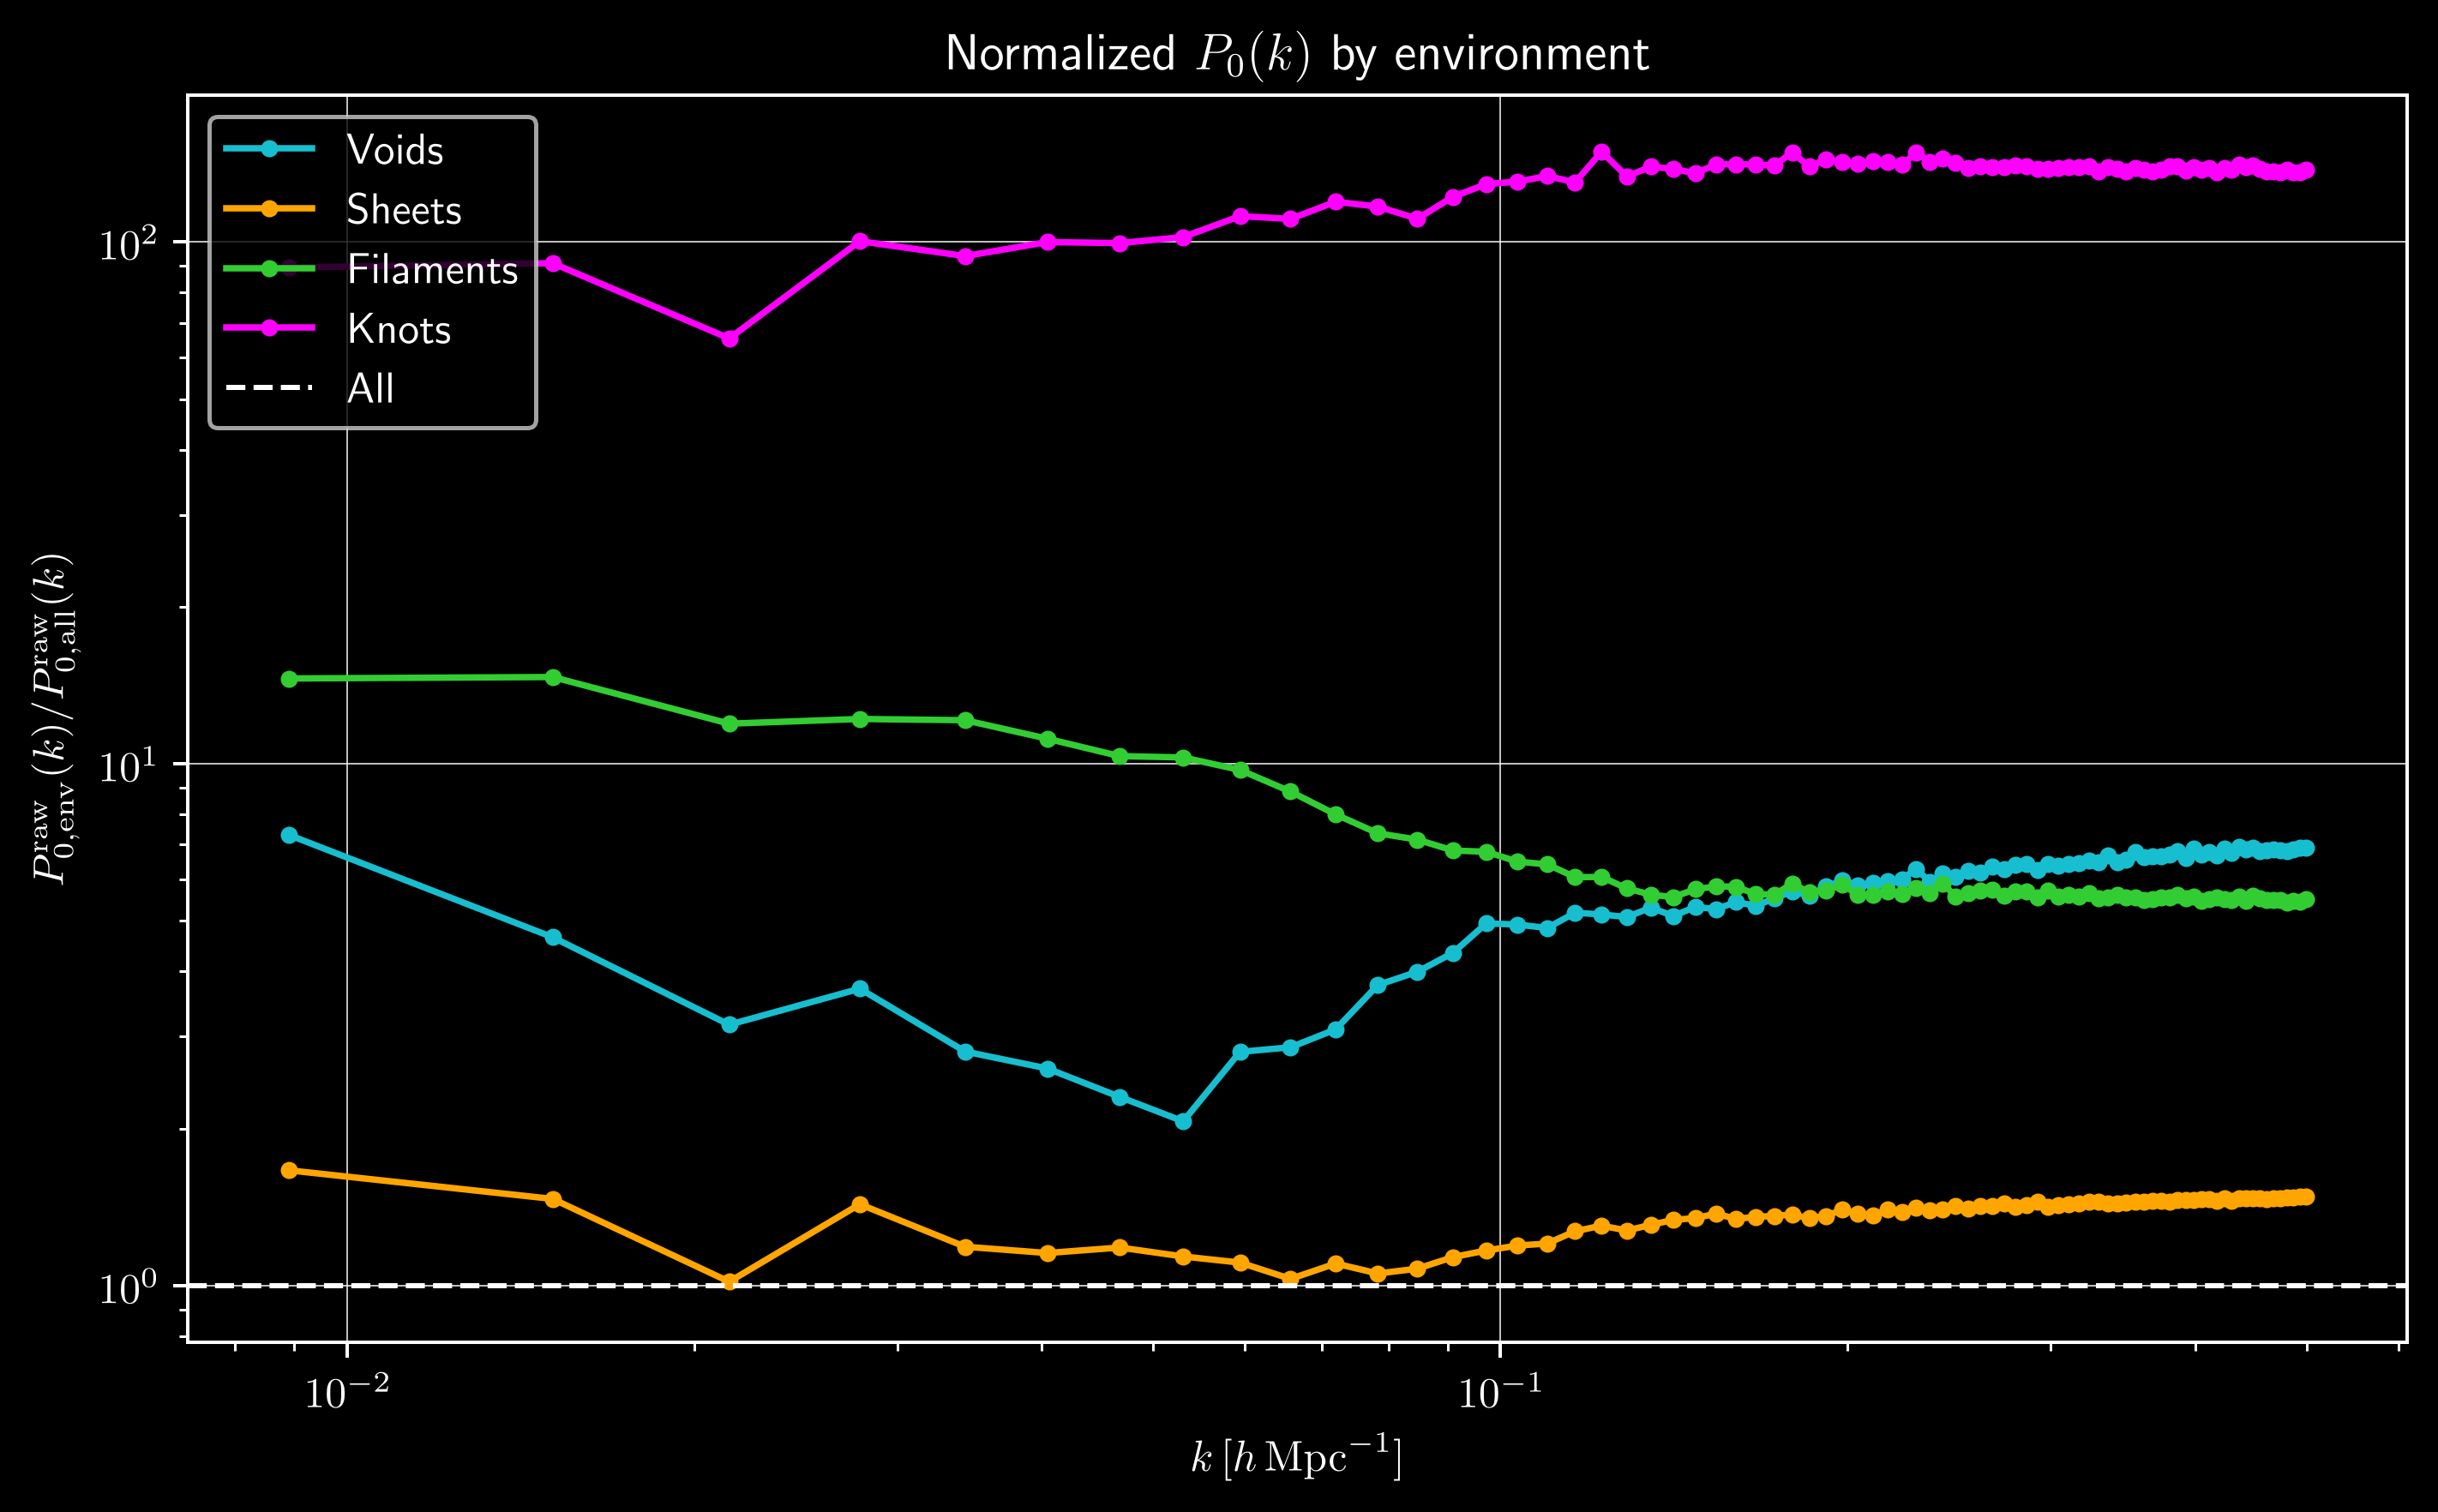

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k[mask_ratio], ratio_v[mask_ratio], '.-', color='#17becf', label='Voids')
ax.plot(k[mask_ratio], ratio_s[mask_ratio], '.-', color='orange', label='Sheets')
ax.plot(k[mask_ratio], ratio_f[mask_ratio], '.-', color='limegreen', label='Filaments')
ax.plot(k[mask_ratio], ratio_k[mask_ratio], '.-', color='magenta', label='Knots')

ax.axhline(1.0, color='white', linestyle='--', linewidth=1.2, label='All')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{0,\mathrm{env}}^{\mathrm{raw}}(k)'
              r'/P_{0,\mathrm{all}}^{\mathrm{raw}}(k)$')

ax.set_title(r'Normalized $P_0(k)$ by environment')

ax.grid(linewidth=0.3)
ax.legend()

plt.tight_layout()
plt.show()